In [5]:
import pandas as pd

In [6]:

file_path = "../data/raw/national_ghg_inventory.csv"

df = pd.read_csv(
    file_path,
    encoding="utf-8-sig",
    keep_default_na=False
)

keep_default_na=False를 사용해 원본의 NA 값을 그대로 불러왔다.

이 데이터에서 NA는 단순한 결측값이 아니라 의미를 가진 표기기호이기 때문에,
Pandas가 자동으로 NaN으로 처리하지 않도록 원본값을 보존했다.

먼저 원본 데이터가 어떤 구조로 되어 있는지 확인해본다.

In [7]:
df.head()

,분야 및 연도,1990,1991,1992,1993,1994,1995,1996,1997,1998,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,총배출량(kt CO2-eq),310565.51,341226.26,368799.41,403692.61,432772.12,464442.2,501209.44,526093.71,459853.43,...,722649.46,725053.11,735559.69,756270.39,780140.33,757150.53,709472.66,739507.44,722032.63,707199.78
1,순배출량,271459.59,306083.96,334510.09,370978.63,397705.23,431129.83,464486.19,484371.9,409757.66,...,675487.13,677270.78,687326.63,713405.1,738561.86,718483.38,670622.79,700612.71,684147.15,667766.58
2,에너지,234518,257373.99,273799.57,300406.06,323220.73,348030.47,381603.37,398442.5,339897.49,...,563930.76,564439.95,575763.34,590773.13,613672.85,590489.02,547485.07,570498.72,555630.65,544988.3
3,A 연료연소,223523.85,246909.94,264283.62,291685.45,315438.69,341032.8,375034.97,392216.4,333921.05,...,559859.57,560457.81,571819.46,587007.3,609984.87,586935.42,544027.04,567078.28,552228.86,541746.31
4,A 연료연소_1 에너지산업,42004.07,49945.73,59044.99,67233.27,81318.26,91952.43,110080.09,120575.53,107952.39,...,263946.83,262304.42,263880.35,273961.83,297732.94,279023.23,246767.98,259488.54,257606.74,248155.39


In [8]:
df.shape

(162, 35)

In [9]:
df.columns

Index(['분야 및 연도', '1990', '1991', '1992', '1993', '1994', '1995', '1996',
       '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005',
       '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014',
       '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023'],
      dtype='str')

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 162 entries, 0 to 161
Data columns (total 35 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   분야 및 연도  162 non-null    str  
 1   1990     162 non-null    str  
 2   1991     162 non-null    str  
 3   1992     162 non-null    str  
 4   1993     162 non-null    str  
 5   1994     162 non-null    str  
 6   1995     162 non-null    str  
 7   1996     162 non-null    str  
 8   1997     162 non-null    str  
 9   1998     162 non-null    str  
 10  1999     162 non-null    str  
 11  2000     162 non-null    str  
 12  2001     162 non-null    str  
 13  2002     162 non-null    str  
 14  2003     162 non-null    str  
 15  2004     162 non-null    str  
 16  2005     162 non-null    str  
 17  2006     162 non-null    str  
 18  2007     162 non-null    str  
 19  2008     162 non-null    str  
 20  2009     162 non-null    str  
 21  2010     162 non-null    str  
 22  2011     162 non-null    str  
 23  2

데이터의 상위 행, 크기, 컬럼, 자료형을 확인했다.

- 총 162개의 행과 35개의 열로 이루어져 있다.
- 1990년부터 2023년까지의 데이터를 가지고 있다.
- 배출량에는 숫자뿐만 아니라 NO, NA, IE, NE 등의 문자열도 같이 들어 있다.
- 이 상태에서는 바로 수치 분석을 하기 어렵기 때문에 전처리가 필요하다.

원본 데이터는 Wide Format, 즉 넓은 형태로 되어 있다.

한 분야의 여러 연도 데이터가 각각의 열로 옆으로 펼쳐져 있는 구조이다.

이번 분석에서는 이를 Long Format으로 바꾸려고 한다.

Long Format은 연도를 하나의 열로 만들고,
각 연도에 해당하는 배출량을 행 단위로 세로로 쌓는 구조이다.

이렇게 바꾸는 이유는 연도를 하나의 변수로 다루기 위해서이다.

Long Format으로 바꾸면 특정 연도나 기간을 조건으로 조회하기 쉽고,
연도별 비교, 집계, 증감률 계산, 시각화, SQL 분석을 하기에도 편해진다.

In [11]:
long_df = df.melt(
    id_vars="분야 및 연도",
    var_name="연도",
    value_name="배출량_원본"
)

long_df.head()

,분야 및 연도,연도,배출량_원본
0,총배출량(kt CO2-eq),1990,310565.51
1,순배출량,1990,271459.59
2,에너지,1990,234518
3,A 연료연소,1990,223523.85
4,A 연료연소_1 에너지산업,1990,42004.07


df.melt()를 사용해 Wide Format을 Long Format으로 변환했다.

id_vars에는 '분야 및 연도'를 넣어 이 컬럼은 그대로 유지했다.

var_name="연도"를 사용해 기존의 1990, 1991, ... 2023 컬럼명을
하나의 '연도' 컬럼으로 만들었다.

value_name="배출량_원본"을 사용해 각 연도에 있던 값을 하나의 컬럼으로 모았다.

아직 전처리하지 않은 값을 그대로 가지고 있기 때문에
컬럼 이름을 '배출량_원본'으로 정했다.

In [12]:
long_df.shape

(5508, 3)

In [13]:
long_df["배출량"] = pd.to_numeric(
    long_df["배출량_원본"],
    errors="coerce"
)

long_df.head()

,분야 및 연도,연도,배출량_원본,배출량
0,총배출량(kt CO2-eq),1990,310565.51,310565.51
1,순배출량,1990,271459.59,271459.59
2,에너지,1990,234518,234518.00
3,A 연료연소,1990,223523.85,223523.85
4,A 연료연소_1 에너지산업,1990,42004.07,42004.07


배출량_원본에는 실제 배출량 수치와 NO, NA, IE, NE 등의 표기기호가 같이 들어 있다.

이 상태에서는 수치 계산을 할 수 없기 때문에
pd.to_numeric()을 사용해 숫자로 변환할 수 있는 값만 새로운 '배출량' 컬럼에 저장했다.

숫자로 변환할 수 없는 값은 errors="coerce"를 사용해 NaN으로 처리했다.

원본 컬럼을 바로 바꾸지 않고 새로운 컬럼을 만든 이유는
NO, NA, IE, NE 등의 원래 정보를 그대로 보존하기 위해서이다.

즉, '배출량_원본'은 원래 데이터를 확인하는 용도이고,
'배출량'은 실제 계산과 분석에 사용하는 용도이다.

In [14]:
long_df["연도"] = long_df["연도"].astype(int)
long_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5508 entries, 0 to 5507
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   분야 및 연도  5508 non-null   str    
 1   연도       5508 non-null   int64  
 2   배출량_원본   5508 non-null   str    
 3   배출량      4214 non-null   float64
dtypes: float64(1), int64(1), str(2)
memory usage: 172.3 KB


연도 컬럼을 문자열에서 정수형으로 변환했다.

이후 특정 연도나 기간을 조건으로 조회하고,
연도별 비교와 분석을 편하게 하기 위해 숫자형으로 바꿨다.

info()를 사용해 연도 컬럼이 int64로 정상적으로 변환되었는지도 확인했다.

In [15]:
long_df.loc[
    long_df["배출량"].isna(),
    "배출량_원본"
].value_counts(dropna=False)


배출량_원본
NO            658
NO, NE        192
NO,IE         102
IE             68
NO, NE, IE     68
               68
NA, IE         34
NA             34
C              34
NO, IE         25
NO, NA          7
NE              4
Name: count, dtype: int64

배출량 컬럼에서 NaN으로 처리된 값들이 원래 어떤 값이었는지 확인했다.

숫자로 변환되지 않았다고 해서 모두 같은 결측값으로 볼 수 없기 때문이다.

배출량이 NaN인 행을 먼저 찾고,
배출량_원본 컬럼을 확인해 NO, NA, IE, NE 등의 표기기호가
각각 몇 번 나타나는지 확인했다.

이 과정을 통해 숫자로 변환되지 않은 값을 바로 삭제하거나 0으로 바꾸지 않고,
원래 어떤 의미를 가진 값인지 먼저 확인했다.

In [16]:
long_df["상태"] = long_df["배출량_원본"].where(
    long_df["배출량"].isna(),
    "수치"
)
long_df.head()

,분야 및 연도,연도,배출량_원본,배출량,상태
0,총배출량(kt CO2-eq),1990,310565.51,310565.51,수치
1,순배출량,1990,271459.59,271459.59,수치
2,에너지,1990,234518,234518.00,수치
3,A 연료연소,1990,223523.85,223523.85,수치
4,A 연료연소_1 에너지산업,1990,42004.07,42004.07,수치


배출량 컬럼은 수치 분석에 사용하고,
숫자로 변환할 수 없는 표기기호는 따로 관리하기 위해 '상태' 컬럼을 만들었다.

숫자로 변환된 값은 '수치'로 표시하고,
NO, NA, IE, NE 등의 값은 원본 그대로 상태 컬럼에 남겼다.

이렇게 해서 숫자 분석을 위한 값과 원본의 표기정보를 같이 보존했다.

In [17]:
(long_df["배출량_원본"] == "").sum()

np.int64(68)

숫자로 변환되지 않은 값 중에는 표기기호뿐만 아니라 실제 빈칸도 있을 수 있기 때문에
배출량_원본의 빈 문자열 개수를 확인했다.

확인 결과 실제 빈칸은 68개였고,
빈칸이 어떤 분야와 연도에 있는지도 직접 확인했다.

이를 통해 NO, NA, IE, NE와 같은 표기기호와
실제로 값이 비어 있는 데이터를 구분했다.배출량 원본 데이터에 실제 빈칸이 몇 개 있는지확인하기 위해 다음과 같은 코드를 작성하였다.


In [18]:
long_df[
    long_df["배출량_원본"] == ""
].head(20)

,분야 및 연도,연도,배출량_원본,배출량,상태
136,F 기타토지_1 기타토지로 유지된 기타토지,1990,,NaN,
156,별도항목(Memo Item),1990,,NaN,
298,F 기타토지_1 기타토지로 유지된 기타토지,1991,,NaN,
318,별도항목(Memo Item),1991,,NaN,
460,F 기타토지_1 기타토지로 유지된 기타토지,1992,,NaN,
480,별도항목(Memo Item),1992,,NaN,
622,F 기타토지_1 기타토지로 유지된 기타토지,1993,,NaN,
642,별도항목(Memo Item),1993,,NaN,
784,F 기타토지_1 기타토지로 유지된 기타토지,1994,,NaN,
804,별도항목(Memo Item),1994,,NaN,


실제 빈칸은 상태 컬럼에서 따로 구분할 수 있도록 '빈칸'으로 표시했다.

그 후 value_counts()를 사용해
수치, NO, NA, IE, NE, 빈칸 등의 상태가 각각 몇 개인지 확인했다.

이를 통해 상태 컬럼이 의도한 대로 잘 만들어졌는지 점검했다.

In [19]:
long_df.loc[
    long_df["배출량_원본"] == "",
    "상태"
] = "빈칸"

In [20]:
long_df["상태"].value_counts()

상태
수치            4214
NO             658
NO, NE         192
NO,IE          102
IE              68
NO, NE, IE      68
빈칸              68
NA, IE          34
NA              34
C               34
NO, IE          25
NO, NA           7
NE               4
Name: count, dtype: int64

상태 컬럼의 value_counts()를 통해 수치값과 NO, NA, IE, NE, 빈칸 등 각 상태의 발생 빈도를 확인하고, 전처리 결과가 정상적으로 반영되었는지 점검하였다.

In [21]:
long_df.loc[
    long_df["상태"].str.contains(",", na=False),
    "상태"
].value_counts()

상태
NO, NE        192
NO,IE         102
NO, NE, IE     68
NA, IE         34
NO, IE         25
NO, NA          7
Name: count, dtype: int64

상태 값을 확인해보니 NO, IE와 같이
두 개 이상의 표기기호가 같이 들어 있는 경우도 있었다.

따라서 쉼표가 포함된 상태만 따로 추출해
어떤 조합이 있고 각각 몇 번 나타나는지 확인했다.

이 과정을 통해 이후 표기기호를 정리하고 분류하기 전에
복합 표기가 어떤 형태로 들어 있는지 먼저 확인했다.


In [22]:
long_df["상태"] = long_df["상태"].str.replace(
    r"\s*,\s*",
    ", ",
    regex=True
)

long_df["상태"].value_counts()

상태
수치            4214
NO             658
NO, NE         192
NO, IE         127
IE              68
NO, NE, IE      68
빈칸              68
NA, IE          34
NA              34
C               34
NO, NA           7
NE               4
Name: count, dtype: int64

상태 값을 확인해보니 같은 의미인데 표기 방식이 다른 값이 있었다.

예를 들어 NO,IE와 NO, IE는 같은 의미이지만,
쉼표 뒤의 공백 차이 때문에 Pandas에서는 서로 다른 값으로 인식하고 있었다.

따라서 str.replace()를 사용해 쉼표 앞뒤의 공백을 정리하고
복합 표기 형식을 동일하게 맞췄다.

정리 후 NO,IE 102개와 NO, IE 25개가
NO, IE 127개로 하나의 값으로 합쳐진 것을 확인했다.

이 작업을 통해 이후 상태별 집계나 SQL 분석에서
같은 의미의 값이 따로 집계되는 문제를 방지했다.

In [23]:
category_df = (
    long_df[["분야 및 연도"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

category_df.head(30)

,분야 및 연도
0,총배출량(kt CO2-eq)
1,순배출량
2,에너지
3,A 연료연소
4,A 연료연소_1 에너지산업
5,A 연료연소_a 공공 전기 및 열 생산
6,A 연료연소_b 석유정제
7,A 연료연소_c 고체연료 제조 및 기타 에너지 산업
8,A 연료연소_2 제조업 및 건설업_2 제조업 및 건설업
9,A 연료연소_a 철강


Long Format으로 변환한 뒤 분야 항목을 확인해보았다.

같은 분야가 연도별로 반복되어 있기 때문에
drop_duplicates()를 사용해 분야 이름을 하나씩만 남겼다.

확인해보니 데이터는 단순히 서로 독립적인 분야로 이루어진 것이 아니라
에너지 → 연료연소 → 에너지산업과 같이 상위 항목과 하위 항목이 같이 들어 있는 계층 구조를 가지고 있었다.

따라서 이후 배출량을 분석할 때 모든 행을 단순히 합계 처리하면
상위 항목과 하위 항목이 중복으로 더해질 수 있다.

이 때문에 분야별 분석을 하기 전에 어떤 수준의 항목을 사용할지 구분하는 과정이 필요하다.


In [24]:
main_categories = [
    "총배출량(kt CO2-eq)",
    "순배출량",
    "에너지",
    "산업공정 및 제품사용",
    "농업",
    "LULUCF",
    "폐기물"
]

main_df = long_df[
    long_df["분야 및 연도"].isin(main_categories)
].copy()

main_df.head(10)

,분야 및 연도,연도,배출량_원본,배출량,상태
0,총배출량(kt CO2-eq),1990,310565.51,310565.51,수치
1,순배출량,1990,271459.59,271459.59,수치
2,에너지,1990,234518,234518.00,수치
43,산업공정 및 제품사용,1990,37807.9,37807.90,수치
88,농업,1990,24800.27,24800.27,수치
115,LULUCF,1990,-39105.93,-39105.93,수치
140,폐기물,1990,13439.35,13439.35,수치
162,총배출량(kt CO2-eq),1991,341226.26,341226.26,수치
163,순배출량,1991,306083.96,306083.96,수치
164,에너지,1991,257373.99,257373.99,수치


In [25]:
main_df[
    main_df["연도"] == 2023
][["분야 및 연도", "연도", "배출량"]]

,분야 및 연도,연도,배출량
5346,총배출량(kt CO2-eq),2023,707199.78
5347,순배출량,2023,667766.58
5348,에너지,2023,544988.30
5389,산업공정 및 제품사용,2023,121502.15
5434,농업,2023,22537.34
5461,LULUCF,2023,-39433.20
5486,폐기물,2023,18172.00


원본 데이터에는 상위 분야와 세부 분야가 같이 들어 있기 때문에
모든 배출량을 단순히 합치면 중복 집계가 발생할 수 있다.

따라서 국가 전체 배출구조를 분석하기 위해
총배출량, 순배출량, 에너지, 산업공정 및 제품사용,
농업, LULUCF, 폐기물 항목만 따로 추출해 main_df를 만들었다.

2023년 데이터를 확인해보니 에너지가 가장 큰 배출량을 가지고 있었고,
산업공정 및 제품사용, 농업, 폐기물 순으로 나타났다.

또한 LULUCF는 음수값을 가지고 있었으며,
총배출량에서 LULUCF의 흡수량을 반영하면 순배출량이 되는 구조라는 것을 확인했다.

이후 국가 전체의 연도별 배출 변화는 main_df를 사용해 분석하려고 한다.

In [26]:
total_df = main_df[
    main_df["분야 및 연도"] == "총배출량(kt CO2-eq)"
][["연도", "배출량"]].copy()

total_df.head()

,연도,배출량
0,1990,310565.51
162,1991,341226.26
324,1992,368799.41
486,1993,403692.61
648,1994,432772.12


In [27]:
start_value = total_df.loc[
    total_df["연도"] == 1990,
    "배출량"
].iloc[0]

end_value = total_df.loc[
    total_df["연도"] == 2023,
    "배출량"
].iloc[0]

change = end_value - start_value

change_rate = (
    change / start_value
) * 100

print("1990년 배출량:", start_value)
print("2023년 배출량:", end_value)
print("증가량:", change)
print("증가율:", round(change_rate, 2), "%")

1990년 배출량: 310565.51
2023년 배출량: 707199.78
증가량: 396634.27
증가율: 127.71 %


In [28]:
peak_row = total_df.loc[
    total_df["배출량"].idxmax()
]

peak_row

연도       2018.00
배출량    780140.33
Name: 4536, dtype: float64

국가 총배출량이 장기적으로 어떻게 변했는지 확인하기 위해
총배출량 데이터만 따로 추출해 분석했다.

1990년 총배출량은 약 310,566 kt CO2-eq였고,
2023년에는 약 707,200 kt CO2-eq로 증가했다.

1990년과 비교하면 약 396,634 kt CO2-eq 증가했으며,
증가율은 약 127.7%로 나타났다.

또한 전체 기간 중 가장 높은 배출량은 2018년의 약 780,140 kt CO2-eq였다.

이를 통해 장기적으로는 총배출량이 크게 증가했지만,
2018년을 정점으로 최근에는 감소하는 흐름이 나타나고 있다는 점을 확인할 수 있었다.

In [29]:
total_df["전년대비_증감량"] = total_df["배출량"].diff()

total_df["전년대비_증감률"] = (
    total_df["배출량"].pct_change() * 100
)

total_df.head(10)

,연도,배출량,전년대비_증감량,전년대비_증감률
0,1990,310565.51,NaN,NaN
162,1991,341226.26,30660.75,9.872555
324,1992,368799.41,27573.15,8.080606
486,1993,403692.61,34893.20,9.461295
648,1994,432772.12,29079.51,7.203379
810,1995,464442.20,31670.08,7.317958
972,1996,501209.44,36767.24,7.916430
1134,1997,526093.71,24884.27,4.964845
1296,1998,459853.43,-66240.28,-12.590966
1458,1999,500237.77,40384.34,8.782003


In [30]:
total_df.sort_values(
    "전년대비_증감량",
    ascending=False
).head(5)

,연도,배출량,전년대비_증감량,전년대비_증감률
3240,2010,689956.60,57085.42,9.020069
1458,1999,500237.77,40384.34,8.782003
972,1996,501209.44,36767.24,7.916430
486,1993,403692.61,34893.20,9.461295
1620,2000,533628.80,33391.03,6.675032


국가 총배출량이 전년도와 비교해 어떻게 변했는지 확인하기 위해
연도별 증감량과 증감률을 계산했다.

diff()를 사용해 전년도와의 배출량 차이를 구했고,
pct_change()를 사용해 전년 대비 변화율을 계산했다.

1990년은 비교할 이전 연도가 없기 때문에
증감량과 증감률이 NaN으로 나타났다.

분석 결과 가장 큰 증가폭은 2010년에 나타났고,
전년보다 약 57,085 kt CO2-eq 증가했다.

반대로 가장 큰 감소폭은 1998년에 나타났으며,
약 66,240 kt CO2-eq 감소했다.

또한 2020년에도 약 47,678 kt CO2-eq의 큰 감소가 나타났다.

이를 통해 전체 배출량의 장기적인 증가뿐만 아니라
특정 연도에 배출량 변화가 크게 나타난 시점도 확인할 수 있었다.

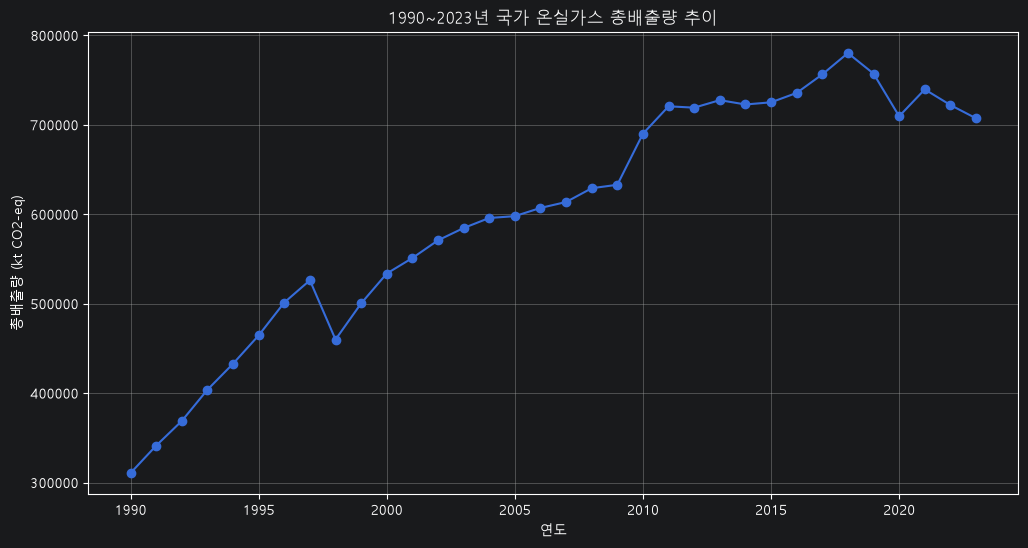

In [31]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

plt.figure(figsize=(12, 6))

plt.plot(
    total_df["연도"],
    total_df["배출량"],
    marker="o"
)

plt.title("1990~2023년 국가 온실가스 총배출량 추이")
plt.xlabel("연도")
plt.ylabel("총배출량 (kt CO2-eq)")

plt.grid(True)
plt.show()

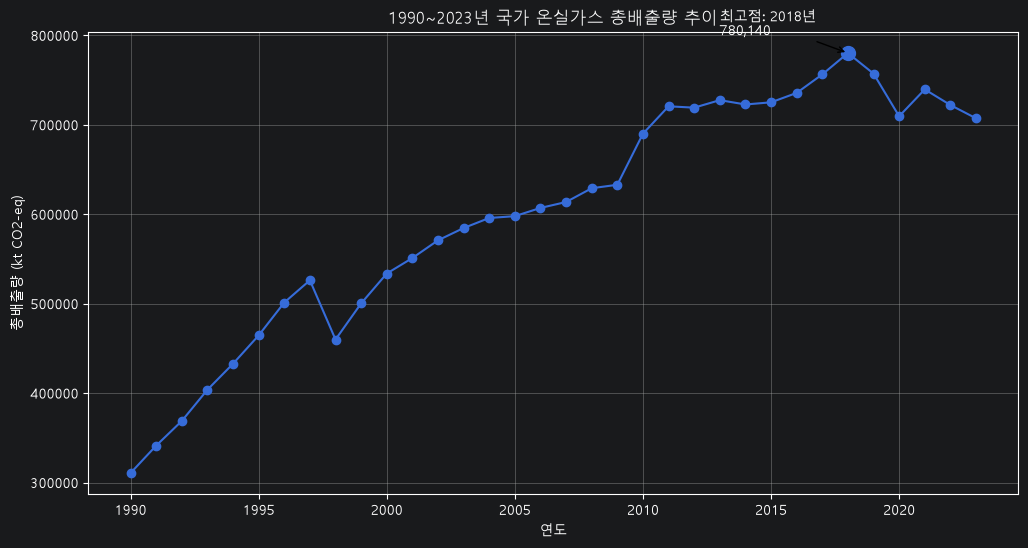

In [32]:
peak_year = total_df.loc[
    total_df["배출량"].idxmax(),
    "연도"
]

peak_value = total_df["배출량"].max()

plt.figure(figsize=(12, 6))

plt.plot(
    total_df["연도"],
    total_df["배출량"],
    marker="o"
)

plt.scatter(
    peak_year,
    peak_value,
    s=100
)

plt.annotate(
    f"최고점: {peak_year}년\n{peak_value:,.0f}",
    xy=(peak_year, peak_value),
    xytext=(peak_year - 5, peak_value + 20000),
    arrowprops={"arrowstyle": "->"}
)

plt.title("1990~2023년 국가 온실가스 총배출량 추이")
plt.xlabel("연도")
plt.ylabel("총배출량 (kt CO2-eq)")
plt.grid(True)

plt.show()

국가 총배출량의 장기적인 변화를 한눈에 보기 위해
1990년부터 2023년까지의 총배출량을 선 그래프로 나타냈다.

그래프를 확인해보니 전체적으로는 1990년 이후 배출량이 크게 증가하는 흐름을 보였다.

중간에 일부 감소한 시기도 있었지만 다시 증가했고,
2018년에 약 780,140 kt CO2-eq로 가장 높은 배출량을 기록했다.

2018년 이후에는 이전보다 감소하는 흐름이 나타났으며,
2023년 총배출량은 약 707,200 kt CO2-eq로 확인됐다.

앞에서 계산한 연도별 증감량과 그래프를 같이 확인하면서
단순히 장기적인 증가뿐만 아니라 배출량 변화가 크게 나타난 시점도 확인할 수 있었다.

In [33]:
sectors = [
    "에너지",
    "산업공정 및 제품사용",
    "농업",
    "폐기물"
]

sector_2023 = main_df[
    (main_df["연도"] == 2023) &
    (main_df["분야 및 연도"].isin(sectors))
][["분야 및 연도", "배출량"]].copy()

sector_2023

,분야 및 연도,배출량
5348,에너지,544988.30
5389,산업공정 및 제품사용,121502.15
5434,농업,22537.34
5486,폐기물,18172.00


In [34]:
total_2023 = total_df.loc[
    total_df["연도"] == 2023,
    "배출량"
].iloc[0]

sector_2023["비중(%)"] = (
    sector_2023["배출량"] / total_2023 * 100
).round(2)

sector_2023 = sector_2023.sort_values(
    "비중(%)",
    ascending=False
)

sector_2023

,분야 및 연도,배출량,비중(%)
5348,에너지,544988.30,77.06
5389,산업공정 및 제품사용,121502.15,17.18
5434,농업,22537.34,3.19
5486,폐기물,18172.00,2.57


2023년 국가 총배출량에서 각 분야가 차지하는 비중을 확인했다.

총배출량은 에너지, 산업공정 및 제품사용, 농업, 폐기물 분야를 기준으로 비교했고,
LULUCF는 흡수량을 포함하는 항목이기 때문에 이번 총배출량 비중 계산에서는 제외했다.

분석 결과 에너지 분야가 약 77.06%로 가장 높은 비중을 차지했다.

산업공정 및 제품사용은 약 17.18%,
농업은 약 3.19%,
폐기물은 약 2.57%로 나타났다.

이를 통해 국가 온실가스 배출구조에서 에너지 분야의 영향이 가장 크다는 것을 확인할 수 있었다.

따라서 이후 감축 우선순위를 분석할 때도
에너지 분야의 변화가 전체 배출량에 어떤 영향을 주는지 먼저 확인할 필요가 있다고 판단했다.

In [35]:
compare_years = [1990, 2023]

compare_df = main_df[
    (main_df["연도"].isin(compare_years)) &
    (main_df["분야 및 연도"].isin(sectors))
][["분야 및 연도", "연도", "배출량"]].copy()

compare_df

,분야 및 연도,연도,배출량
2,에너지,1990,234518.00
43,산업공정 및 제품사용,1990,37807.90
88,농업,1990,24800.27
140,폐기물,1990,13439.35
5348,에너지,2023,544988.30
5389,산업공정 및 제품사용,2023,121502.15
5434,농업,2023,22537.34
5486,폐기물,2023,18172.00


In [36]:
total_compare = total_df[
    total_df["연도"].isin(compare_years)
][["연도", "배출량"]].rename(
    columns={"배출량": "총배출량"}
)

compare_df = compare_df.merge(
    total_compare,
    on="연도",
    how="left"
)

compare_df

,분야 및 연도,연도,배출량,총배출량
0,에너지,1990,234518.00,310565.51
1,산업공정 및 제품사용,1990,37807.90,310565.51
2,농업,1990,24800.27,310565.51
3,폐기물,1990,13439.35,310565.51
4,에너지,2023,544988.30,707199.78
5,산업공정 및 제품사용,2023,121502.15,707199.78
6,농업,2023,22537.34,707199.78
7,폐기물,2023,18172.00,707199.78


In [37]:
compare_df["비중(%)"] = (
    compare_df["배출량"]
    / compare_df["총배출량"]
    * 100
).round(2)

compare_df

,분야 및 연도,연도,배출량,총배출량,비중(%)
0,에너지,1990,234518.00,310565.51,75.51
1,산업공정 및 제품사용,1990,37807.90,310565.51,12.17
2,농업,1990,24800.27,310565.51,7.99
3,폐기물,1990,13439.35,310565.51,4.33
4,에너지,2023,544988.30,707199.78,77.06
5,산업공정 및 제품사용,2023,121502.15,707199.78,17.18
6,농업,2023,22537.34,707199.78,3.19
7,폐기물,2023,18172.00,707199.78,2.57


In [38]:
share_pivot = compare_df.pivot(
    index="분야 및 연도",
    columns="연도",
    values="비중(%)"
)

share_pivot

연도,1990,2023
분야 및 연도,,
농업,7.99,3.19
산업공정 및 제품사용,12.17,17.18
에너지,75.51,77.06
폐기물,4.33,2.57


In [39]:
share_pivot["비중변화(%p)"] = (
    share_pivot[2023] - share_pivot[1990]
).round(2)

share_pivot

연도,1990,2023,비중변화(%p)
분야 및 연도,,,
농업,7.99,3.19,-4.80
산업공정 및 제품사용,12.17,17.18,5.01
에너지,75.51,77.06,1.55
폐기물,4.33,2.57,-1.76


국가 온실가스 배출구조가 장기적으로 어떻게 변했는지 확인하기 위해
1990년과 2023년의 분야별 배출 비중을 비교했다.

각 분야의 배출량을 해당 연도의 총배출량으로 나누어 비중을 계산했고,
두 연도를 비교하기 쉽도록 pivot()을 사용해 표 형태로 정리했다.

분석 결과 에너지는 1990년 약 75.51%에서
2023년 약 77.06%로 1.55%p 증가했다.

특히 산업공정 및 제품사용은
약 12.17%에서 17.18%로 5.01%p 증가해
주요 분야 중 비중 증가가 가장 크게 나타났다.

반면 농업은 약 7.99%에서 3.19%로 감소했고,
폐기물도 약 4.33%에서 2.57%로 감소했다.

이를 통해 국가 온실가스 배출구조에서
에너지의 높은 비중이 계속 유지되고 있으며,
산업공정 및 제품사용의 영향도 이전보다 커졌다는 것을 확인할 수 있었다.

In [40]:
amount_pivot = compare_df.pivot(
    index="분야 및 연도",
    columns="연도",
    values="배출량"
)

amount_pivot

연도,1990,2023
분야 및 연도,,
농업,24800.27,22537.34
산업공정 및 제품사용,37807.90,121502.15
에너지,234518.00,544988.30
폐기물,13439.35,18172.00


In [41]:
amount_pivot["증감량"] = (
    amount_pivot[2023] - amount_pivot[1990]
)

amount_pivot

연도,1990,2023,증감량
분야 및 연도,,,
농업,24800.27,22537.34,-2262.93
산업공정 및 제품사용,37807.90,121502.15,83694.25
에너지,234518.00,544988.30,310470.30
폐기물,13439.35,18172.00,4732.65


In [42]:
amount_pivot["증감률(%)"] = (
    amount_pivot["증감량"]
    / amount_pivot[1990]
    * 100
).round(2)

amount_pivot

연도,1990,2023,증감량,증감률(%)
분야 및 연도,,,,
농업,24800.27,22537.34,-2262.93,-9.12
산업공정 및 제품사용,37807.90,121502.15,83694.25,221.37
에너지,234518.00,544988.30,310470.30,132.39
폐기물,13439.35,18172.00,4732.65,35.21


1990년과 2023년의 분야별 비중뿐만 아니라
실제 배출량이 얼마나 증가하거나 감소했는지도 확인했다.

각 분야의 1990년과 2023년 배출량을 비교하고,
2023년 값에서 1990년 값을 빼 증감량을 계산했다.

또한 증감량을 1990년 배출량으로 나누어
장기적인 증감률도 확인했다.

분석 결과 에너지 분야는 약 310,470 kt CO2-eq 증가해
주요 분야 중 실제 증가량이 가장 크게 나타났다.

산업공정 및 제품사용은 약 83,694 kt CO2-eq 증가했으며,
증가율은 약 221.37%로 주요 분야 중 가장 높았다.

반면 농업은 약 2,263 kt CO2-eq 감소해
1990년보다 약 9.12% 낮아졌다.

이를 통해 실제 국가 배출량 증가에는 에너지 분야의 영향이 가장 컸지만,
산업공정 및 제품사용도 장기적으로 빠르게 증가한 분야라는 것을 확인할 수 있었다.

In [43]:
# 2018년과 2023년의 주요 분야별 배출량을 비교하기 위한 데이터 추출

recent_compare = main_df[
    (main_df["연도"].isin([2018, 2023])) &
    (main_df["분야 및 연도"].isin(sectors))
][["분야 및 연도", "연도", "배출량"]].copy()

recent_compare

,분야 및 연도,연도,배출량
4538,에너지,2018,613672.85
4579,산업공정 및 제품사용,2018,123823.34
4624,농업,2018,23307.54
4676,폐기물,2018,19336.59
5348,에너지,2023,544988.30
5389,산업공정 및 제품사용,2023,121502.15
5434,농업,2023,22537.34
5486,폐기물,2023,18172.00


In [44]:
# 분야별 2018년과 2023년 배출량을 한 행에서 비교할 수 있도록 표 형태로 변환

recent_pivot = recent_compare.pivot(
    index="분야 및 연도",
    columns="연도",
    values="배출량"
)

recent_pivot

연도,2018,2023
분야 및 연도,,
농업,23307.54,22537.34
산업공정 및 제품사용,123823.34,121502.15
에너지,613672.85,544988.30
폐기물,19336.59,18172.00


In [45]:
# 2018년 대비 2023년에 각 분야의 배출량이 얼마나 증가하거나 감소했는지 계산

recent_pivot["증감량"] = (
    recent_pivot[2023] - recent_pivot[2018]
)

recent_pivot

연도,2018,2023,증감량
분야 및 연도,,,
농업,23307.54,22537.34,-770.20
산업공정 및 제품사용,123823.34,121502.15,-2321.19
에너지,613672.85,544988.30,-68684.55
폐기물,19336.59,18172.00,-1164.59


In [46]:
# 각 분야의 2018년 대비 2023년 배출량 변화율을 계산

recent_pivot["증감률(%)"] = (
    recent_pivot["증감량"]
    / recent_pivot[2018]
    * 100
).round(2)

recent_pivot

연도,2018,2023,증감량,증감률(%)
분야 및 연도,,,,
농업,23307.54,22537.34,-770.20,-3.30
산업공정 및 제품사용,123823.34,121502.15,-2321.19,-1.87
에너지,613672.85,544988.30,-68684.55,-11.19
폐기물,19336.59,18172.00,-1164.59,-6.02


2018년은 국가 총배출량이 가장 높았던 시점이기 때문에
2018년과 2023년의 주요 분야별 배출량을 비교했다.

분석 결과 모든 주요 분야에서 배출량이 감소했지만,
에너지 분야의 감소폭이 가장 크게 나타났다.

에너지 분야는 2018년 약 613,673 kt CO2-eq에서
2023년 약 544,988 kt CO2-eq로 감소했으며,
약 68,685 kt CO2-eq 감소했다.

감소율도 약 11.19%로 나타났다.

반면 산업공정 및 제품사용, 농업, 폐기물의 감소량은
에너지 분야에 비해 상대적으로 작았다.

이를 통해 2018년 이후 국가 총배출량 감소에는
에너지 분야의 배출 감소가 가장 큰 영향을 주었다는 것을 확인할 수 있었다.

In [47]:
# 2018년과 2023년의 국가 총배출량을 가져와 전체 감소량 계산

total_2018 = total_df.loc[
    total_df["연도"] == 2018,
    "배출량"
].iloc[0]

total_2023 = total_df.loc[
    total_df["연도"] == 2023,
    "배출량"
].iloc[0]

total_change = total_2023 - total_2018

print("2018년 총배출량:", total_2018)
print("2023년 총배출량:", total_2023)
print("전체 증감량:", total_change)

2018년 총배출량: 780140.33
2023년 총배출량: 707199.78
전체 증감량: -72940.54999999993


In [48]:
# 전체 총배출량 감소 중 각 분야의 감소가 차지하는 비중을 계산

recent_pivot["감소기여도(%)"] = (
    recent_pivot["증감량"]
    / total_change
    * 100
).round(2)

recent_pivot = recent_pivot.sort_values(
    "감소기여도(%)",
    ascending=False
)

recent_pivot

#계산식 : 분야별 증감량 / 전체 총배출량 증감량 × 100

연도,2018,2023,증감량,증감률(%),감소기여도(%)
분야 및 연도,,,,,
에너지,613672.85,544988.30,-68684.55,-11.19,94.17
산업공정 및 제품사용,123823.34,121502.15,-2321.19,-1.87,3.18
폐기물,19336.59,18172.00,-1164.59,-6.02,1.60
농업,23307.54,22537.34,-770.20,-3.30,1.06


2018년 이후 국가 총배출량 감소에 각 분야가 얼마나 영향을 주었는지 확인하기 위해
분야별 감소 기여도를 계산했다.

2018년 총배출량은 약 780,140 kt CO2-eq였고,
2023년에는 약 707,200 kt CO2-eq로 감소했다.

전체적으로 약 72,941 kt CO2-eq가 감소했다.

각 분야의 증감량을 전체 감소량과 비교한 결과
에너지 분야의 감소 기여도가 약 94.17%로 가장 높게 나타났다.

산업공정 및 제품사용은 약 3.18%,
폐기물은 약 1.60%,
농업은 약 1.06%로 나타났다.

이를 통해 2018년 이후 국가 총배출량 감소는
대부분 에너지 분야의 배출 감소에 의해 나타났다는 것을 확인할 수 있었다.

따라서 다음으로는 에너지 분야 안에서
어떤 세부 항목의 감소가 가장 큰 영향을 주었는지 확인할 필요가 있다고 판단했다.

In [49]:
# 에너지 분야의 주요 세부 항목을 따로 지정하기 위한 코드

energy_sectors = [
    "A 연료연소_1 에너지산업",
    "A 연료연소_2 제조업 및 건설업_2 제조업 및 건설업",
    "A 연료연소_3 수송",
    "A 연료연소_4 기타",
    "A 연료연소_5 미분류",
    "B 탈루"
]

In [50]:
# 2018년과 2023년의 에너지 세부 분야별 배출량을 추출하기 위한 코드

energy_compare = long_df[
    (long_df["연도"].isin([2018, 2023])) &
    (long_df["분야 및 연도"].isin(energy_sectors))
][["분야 및 연도", "연도", "배출량"]].copy()

energy_compare

,분야 및 연도,연도,배출량
4540,A 연료연소_1 에너지산업,2018,297732.94
4544,A 연료연소_2 제조업 및 건설업_2 제조업 및 건설업,2018,157209.46
4559,A 연료연소_3 수송,2018,98882.39
4565,A 연료연소_4 기타,2018,53012.02
4571,A 연료연소_5 미분류,2018,3148.07
4572,B 탈루,2018,3687.98
5350,A 연료연소_1 에너지산업,2023,248155.39
5354,A 연료연소_2 제조업 및 건설업_2 제조업 및 건설업,2023,147240.38
5369,A 연료연소_3 수송,2023,97825.94
5375,A 연료연소_4 기타,2023,45502.68


In [51]:
# 에너지 세부 분야별 2018년과 2023년 배출량을 한 행에서 비교하기 위한 코드

energy_pivot = energy_compare.pivot(
    index="분야 및 연도",
    columns="연도",
    values="배출량"
)

energy_pivot

연도,2018,2023
분야 및 연도,,
A 연료연소_1 에너지산업,297732.94,248155.39
A 연료연소_2 제조업 및 건설업_2 제조업 및 건설업,157209.46,147240.38
A 연료연소_3 수송,98882.39,97825.94
A 연료연소_4 기타,53012.02,45502.68
A 연료연소_5 미분류,3148.07,3021.92
B 탈루,3687.98,3241.99


In [52]:
# 2018년 대비 2023년 에너지 세부 분야별 배출량 증감량을 계산하기 위한 코드

energy_pivot["증감량"] = (
    energy_pivot[2023] - energy_pivot[2018]
)

energy_pivot

연도,2018,2023,증감량
분야 및 연도,,,
A 연료연소_1 에너지산업,297732.94,248155.39,-49577.55
A 연료연소_2 제조업 및 건설업_2 제조업 및 건설업,157209.46,147240.38,-9969.08
A 연료연소_3 수송,98882.39,97825.94,-1056.45
A 연료연소_4 기타,53012.02,45502.68,-7509.34
A 연료연소_5 미분류,3148.07,3021.92,-126.15
B 탈루,3687.98,3241.99,-445.99


In [53]:
# 각 에너지 세부 분야의 2018년 대비 2023년 배출량 변화율을 계산하기 위한 코드

energy_pivot["증감률(%)"] = (
    energy_pivot["증감량"]
    / energy_pivot[2018]
    * 100
).round(2)

energy_pivot

연도,2018,2023,증감량,증감률(%)
분야 및 연도,,,,
A 연료연소_1 에너지산업,297732.94,248155.39,-49577.55,-16.65
A 연료연소_2 제조업 및 건설업_2 제조업 및 건설업,157209.46,147240.38,-9969.08,-6.34
A 연료연소_3 수송,98882.39,97825.94,-1056.45,-1.07
A 연료연소_4 기타,53012.02,45502.68,-7509.34,-14.17
A 연료연소_5 미분류,3148.07,3021.92,-126.15,-4.01
B 탈루,3687.98,3241.99,-445.99,-12.09


In [54]:
# 에너지 전체 감소량 중 각 세부 분야가 차지하는 감소 기여도를 계산하기 위한 코드

energy_total_change = (
    main_df.loc[
        (main_df["분야 및 연도"] == "에너지") &
        (main_df["연도"] == 2023),
        "배출량"
    ].iloc[0]
    -
    main_df.loc[
        (main_df["분야 및 연도"] == "에너지") &
        (main_df["연도"] == 2018),
        "배출량"
    ].iloc[0]
)

energy_pivot["감소기여도(%)"] = (
    energy_pivot["증감량"]
    / energy_total_change
    * 100
).round(2)

energy_pivot = energy_pivot.sort_values(
    "감소기여도(%)",
    ascending=False
)

energy_pivot

연도,2018,2023,증감량,증감률(%),감소기여도(%)
분야 및 연도,,,,,
A 연료연소_1 에너지산업,297732.94,248155.39,-49577.55,-16.65,72.18
A 연료연소_2 제조업 및 건설업_2 제조업 및 건설업,157209.46,147240.38,-9969.08,-6.34,14.51
A 연료연소_4 기타,53012.02,45502.68,-7509.34,-14.17,10.93
A 연료연소_3 수송,98882.39,97825.94,-1056.45,-1.07,1.54
B 탈루,3687.98,3241.99,-445.99,-12.09,0.65
A 연료연소_5 미분류,3148.07,3021.92,-126.15,-4.01,0.18


2018년 이후 국가 총배출량 감소에 에너지 분야가 가장 큰 영향을 주었기 때문에
에너지 분야 안에서 어떤 세부 항목의 감소가 가장 컸는지 확인했다.

2018년과 2023년의 에너지산업, 제조업 및 건설업, 수송,
기타, 미분류, 탈루의 배출량을 비교했다.

분석 결과 에너지산업은 약 49,578 kt CO2-eq 감소해
에너지 세부 분야 중 가장 큰 감소폭을 보였다.

에너지 전체 감소량에서 차지하는 기여도도 약 72.18%로 가장 높았다.

제조업 및 건설업은 약 14.51%,
기타 분야는 약 10.93%의 감소 기여도를 보였다.

이를 통해 2018년 이후 에너지 분야의 배출 감소는
주로 에너지산업의 감소에 의해 나타났다는 것을 확인할 수 있었다.

따라서 다음에는 에너지산업 안에서
어떤 세부 항목이 실제 감소를 이끌었는지 더 자세히 확인해볼 필요가 있다고 판단했다

In [55]:
# 에너지산업 안에서 어떤 세부 분야가 배출량 감소에 영향을 주었는지 확인하기 위한 코드

energy_industry_sectors = [
    "A 연료연소_a 공공 전기 및 열 생산",
    "A 연료연소_b 석유정제",
    "A 연료연소_c 고체연료 제조 및 기타 에너지 산업"
]

In [56]:
# 2018년과 2023년의 에너지산업 세부 분야별 배출량을 추출하기 위한 코드

industry_compare = long_df[
    (long_df["연도"].isin([2018, 2023])) &
    (long_df["분야 및 연도"].isin(energy_industry_sectors))
][["분야 및 연도", "연도", "배출량"]].copy()

industry_compare

,분야 및 연도,연도,배출량
4541,A 연료연소_a 공공 전기 및 열 생산,2018,276618.81
4542,A 연료연소_b 석유정제,2018,20289.29
4543,A 연료연소_c 고체연료 제조 및 기타 에너지 산업,2018,824.84
5351,A 연료연소_a 공공 전기 및 열 생산,2023,226959.86
5352,A 연료연소_b 석유정제,2023,19605.15
5353,A 연료연소_c 고체연료 제조 및 기타 에너지 산업,2023,1590.37


In [57]:
# 각 세부 분야의 2018년과 2023년 배출량을 한 행에서 비교하기 위한 코드

industry_pivot = industry_compare.pivot(
    index="분야 및 연도",
    columns="연도",
    values="배출량"
)

industry_pivot

연도,2018,2023
분야 및 연도,,
A 연료연소_a 공공 전기 및 열 생산,276618.81,226959.86
A 연료연소_b 석유정제,20289.29,19605.15
A 연료연소_c 고체연료 제조 및 기타 에너지 산업,824.84,1590.37


In [58]:
# 2018년 대비 2023년에 각 세부 분야의 배출량이 얼마나 변했는지 계산하기 위한 코드

industry_pivot["증감량"] = (
    industry_pivot[2023] - industry_pivot[2018]
)

industry_pivot

연도,2018,2023,증감량
분야 및 연도,,,
A 연료연소_a 공공 전기 및 열 생산,276618.81,226959.86,-49658.95
A 연료연소_b 석유정제,20289.29,19605.15,-684.14
A 연료연소_c 고체연료 제조 및 기타 에너지 산업,824.84,1590.37,765.53


In [59]:
# 각 세부 분야의 2018년 대비 2023년 배출량 변화율을 계산하기 위한 코드

industry_pivot["증감률(%)"] = (
    industry_pivot["증감량"]
    / industry_pivot[2018]
    * 100
).round(2)

industry_pivot

연도,2018,2023,증감량,증감률(%)
분야 및 연도,,,,
A 연료연소_a 공공 전기 및 열 생산,276618.81,226959.86,-49658.95,-17.95
A 연료연소_b 석유정제,20289.29,19605.15,-684.14,-3.37
A 연료연소_c 고체연료 제조 및 기타 에너지 산업,824.84,1590.37,765.53,92.81


In [60]:
# 에너지산업 전체 감소량 중 각 세부 분야의 변화가 차지하는 비중을 계산하기 위한 코드

energy_industry_change = (
    long_df.loc[
        (long_df["분야 및 연도"] == "A 연료연소_1 에너지산업") &
        (long_df["연도"] == 2023),
        "배출량"
    ].iloc[0]
    -
    long_df.loc[
        (long_df["분야 및 연도"] == "A 연료연소_1 에너지산업") &
        (long_df["연도"] == 2018),
        "배출량"
    ].iloc[0]
)

industry_pivot["감소기여도(%)"] = (
    industry_pivot["증감량"]
    / energy_industry_change
    * 100
).round(2)

industry_pivot

연도,2018,2023,증감량,증감률(%),감소기여도(%)
분야 및 연도,,,,,
A 연료연소_a 공공 전기 및 열 생산,276618.81,226959.86,-49658.95,-17.95,100.16
A 연료연소_b 석유정제,20289.29,19605.15,-684.14,-3.37,1.38
A 연료연소_c 고체연료 제조 및 기타 에너지 산업,824.84,1590.37,765.53,92.81,-1.54



약 49,659 kt CO2-eq 감소해 가장 큰 감소폭을 보였다.

석유정제도 소폭 감소했지만,
고체연료 제조 및 기타 에너지 산업은 오히려 배출량이 증가했다.

특히 공공 전기 및 열 생산의 감소량은
에너지산업 전체 감소량의 대부분을 설명하고 있었다.

이를 통해 2018년 이후 에너지산업의 배출 감소는
주로 공공 전기 및 열 생산 부문의 감소에서 나타났다는 것을 확인할 수 있었다.

또한 세부 분야에 따라 감소와 증가가 동시에 나타날 수 있기 때문에
전체 배출량뿐만 아니라 하위 분야의 변화도 같이 확인할 필요가 있다고 판단했다.

In [61]:
# 제조업 및 건설업 안에서 주요 세부 업종별 배출량을 비교하기 위한 코드

manufacturing_sectors = [
    "A 연료연소_a 철강",
    "A 연료연소_b 비철금속",
    "A 연료연소_c 화학",
    "A 연료연소_d 펄프, 제지 및 인쇄",
    "A 연료연소_e 식음료품 가공 및 담배 제조",
    "A 연료연소_f 비금속광물",
    "A 연료연소_g 기타"
]

In [62]:
# 2018년과 2023년의 제조업 세부 업종별 배출량을 추출하기 위한 코드

manufacturing_compare = long_df[
    (long_df["연도"].isin([2018, 2023])) &
    (long_df["분야 및 연도"].isin(manufacturing_sectors))
][["분야 및 연도", "연도", "배출량"]].copy()

manufacturing_compare

,분야 및 연도,연도,배출량
4545,A 연료연소_a 철강,2018,83663.20
4546,A 연료연소_b 비철금속,2018,2927.06
4547,A 연료연소_c 화학,2018,23795.11
4548,"A 연료연소_d 펄프, 제지 및 인쇄",2018,2291.56
4549,A 연료연소_e 식음료품 가공 및 담배 제조,2018,2170.33
4550,A 연료연소_f 비금속광물,2018,13684.83
4551,A 연료연소_g 기타,2018,28677.37
5355,A 연료연소_a 철강,2023,74997.26
5356,A 연료연소_b 비철금속,2023,3775.43
5357,A 연료연소_c 화학,2023,24925.76


In [63]:
# 제조업 세부 업종별 2018년과 2023년 배출량을 한 행에서 비교하기 위한 코드

manufacturing_pivot = manufacturing_compare.pivot(
    index="분야 및 연도",
    columns="연도",
    values="배출량"
)

manufacturing_pivot

연도,2018,2023
분야 및 연도,,
A 연료연소_a 철강,83663.20,74997.26
A 연료연소_b 비철금속,2927.06,3775.43
A 연료연소_c 화학,23795.11,24925.76
"A 연료연소_d 펄프, 제지 및 인쇄",2291.56,2750.24
A 연료연소_e 식음료품 가공 및 담배 제조,2170.33,2065.05
A 연료연소_f 비금속광물,13684.83,15432.97
A 연료연소_g 기타,28677.37,23293.66


In [64]:
# 제조업 세부 업종별로 2018년 대비 2023년 배출량 증감량과 증감률을 계산하기 위한 코드

manufacturing_pivot["증감량"] = (
    manufacturing_pivot[2023] - manufacturing_pivot[2018]
)

manufacturing_pivot["증감률(%)"] = (
    manufacturing_pivot["증감량"]
    / manufacturing_pivot[2018]
    * 100
).round(2)

manufacturing_pivot

연도,2018,2023,증감량,증감률(%)
분야 및 연도,,,,
A 연료연소_a 철강,83663.20,74997.26,-8665.94,-10.36
A 연료연소_b 비철금속,2927.06,3775.43,848.37,28.98
A 연료연소_c 화학,23795.11,24925.76,1130.65,4.75
"A 연료연소_d 펄프, 제지 및 인쇄",2291.56,2750.24,458.68,20.02
A 연료연소_e 식음료품 가공 및 담배 제조,2170.33,2065.05,-105.28,-4.85
A 연료연소_f 비금속광물,13684.83,15432.97,1748.14,12.77
A 연료연소_g 기타,28677.37,23293.66,-5383.71,-18.77


In [65]:
# 2023년 제조업 및 건설업 전체 배출량에서 각 세부 업종이 차지하는 비중을 계산하기 위한 코드

manufacturing_total_2023 = long_df.loc[
    (long_df["분야 및 연도"] ==
     "A 연료연소_2 제조업 및 건설업_2 제조업 및 건설업") &
    (long_df["연도"] == 2023),
    "배출량"
].iloc[0]

manufacturing_pivot["2023년 비중(%)"] = (
    manufacturing_pivot[2023]
    / manufacturing_total_2023
    * 100
).round(2)

manufacturing_pivot = manufacturing_pivot.sort_values(
    "2023년 비중(%)",
    ascending=False
)

manufacturing_pivot

연도,2018,2023,증감량,증감률(%),2023년 비중(%)
분야 및 연도,,,,,
A 연료연소_a 철강,83663.20,74997.26,-8665.94,-10.36,50.94
A 연료연소_c 화학,23795.11,24925.76,1130.65,4.75,16.93
A 연료연소_g 기타,28677.37,23293.66,-5383.71,-18.77,15.82
A 연료연소_f 비금속광물,13684.83,15432.97,1748.14,12.77,10.48
A 연료연소_b 비철금속,2927.06,3775.43,848.37,28.98,2.56
"A 연료연소_d 펄프, 제지 및 인쇄",2291.56,2750.24,458.68,20.02,1.87
A 연료연소_e 식음료품 가공 및 담배 제조,2170.33,2065.05,-105.28,-4.85,1.40


제조업 및 건설업의 배출구조를 더 자세히 확인하기 위해
철강, 비철금속, 화학, 펄프·제지·인쇄, 식음료품, 비금속광물, 기타 업종을 비교했다.

중복 집계를 피하기 위해 같은 계층에 있는 세부 업종만 사용했다.

2018년과 2023년을 비교한 결과
철강은 약 8,666 kt CO2-eq 감소했고,
기타 업종도 약 5,384 kt CO2-eq 감소했다.

반면 비금속광물, 화학, 비철금속 등은
2018년보다 배출량이 증가한 것으로 나타났다.

2023년 제조업 및 건설업 배출량에서 철강이 약 50.94%를 차지해
가장 큰 비중을 가지고 있었다.

화학은 약 16.93%, 기타는 약 15.82%,
비금속광물은 약 10.48%로 나타났다.

철강은 현재 배출 규모가 가장 크기 때문에 여전히 중요한 관리 대상이지만,
2018년 이후에는 배출량이 감소하고 있었다.

반면 화학과 비금속광물은 배출 규모가 비교적 크면서
최근 배출량도 증가하고 있어 추가적으로 확인할 필요가 있다고 판단했다.

In [66]:
# 제조업 세부 업종을 배출 규모가 큰 그룹과 작은 그룹으로 나누기 위해
# 2023년 배출량의 중앙값을 계산하는 코드

emission_median = manufacturing_pivot[2023].median()

print("2023년 배출량 중앙값:", emission_median)

2023년 배출량 중앙값: 15432.97


In [67]:
# 2023년 배출량이 중앙값 이상이면 2점,
# 중앙값보다 작으면 0점을 부여해 배출 규모 점수를 만드는 코드

manufacturing_pivot["규모점수"] = (
    manufacturing_pivot[2023] >= emission_median
).astype(int) * 2

manufacturing_pivot[
    [2023, "규모점수"]
]

연도,2023,규모점수
분야 및 연도,,
A 연료연소_a 철강,74997.26,2
A 연료연소_c 화학,24925.76,2
A 연료연소_g 기타,23293.66,2
A 연료연소_f 비금속광물,15432.97,2
A 연료연소_b 비철금속,3775.43,0
"A 연료연소_d 펄프, 제지 및 인쇄",2750.24,0
A 연료연소_e 식음료품 가공 및 담배 제조,2065.05,0


In [68]:
# 2018년보다 2023년 배출량이 증가한 업종에
# 추가로 1점을 부여하기 위한 코드

manufacturing_pivot["증가점수"] = (
    manufacturing_pivot["증감량"] > 0
).astype(int)

manufacturing_pivot[
    ["증감량", "증가점수"]
]

연도,증감량,증가점수
분야 및 연도,,
A 연료연소_a 철강,-8665.94,0
A 연료연소_c 화학,1130.65,1
A 연료연소_g 기타,-5383.71,0
A 연료연소_f 비금속광물,1748.14,1
A 연료연소_b 비철금속,848.37,1
"A 연료연소_d 펄프, 제지 및 인쇄",458.68,1
A 연료연소_e 식음료품 가공 및 담배 제조,-105.28,0


In [69]:
# 현재 배출 규모와 최근 배출 증가 여부를 함께 반영해
# 업종별 우선순위 점수를 계산하기 위한 코드

manufacturing_pivot["우선순위점수"] = (
    manufacturing_pivot["규모점수"]
    + manufacturing_pivot["증가점수"]
)

manufacturing_pivot[
    [2023, "증감량", "규모점수", "증가점수", "우선순위점수"]
]

연도,2023,증감량,규모점수,증가점수,우선순위점수
분야 및 연도,,,,,
A 연료연소_a 철강,74997.26,-8665.94,2,0,2
A 연료연소_c 화학,24925.76,1130.65,2,1,3
A 연료연소_g 기타,23293.66,-5383.71,2,0,2
A 연료연소_f 비금속광물,15432.97,1748.14,2,1,3
A 연료연소_b 비철금속,3775.43,848.37,0,1,1
"A 연료연소_d 펄프, 제지 및 인쇄",2750.24,458.68,0,1,1
A 연료연소_e 식음료품 가공 및 담배 제조,2065.05,-105.28,0,0,0


In [70]:
# 계산한 점수를 사람이 이해하기 쉬운
# 우선순위 단계로 변환하기 위한 코드

priority_map = {
    3: "1순위",
    2: "2순위",
    1: "3순위",
    0: "4순위"
}

manufacturing_pivot["검토우선순위"] = (
    manufacturing_pivot["우선순위점수"]
    .map(priority_map)
)

In [71]:
# 우선순위 점수가 높은 업종부터 확인하고,
# 같은 점수에서는 2023년 배출량이 큰 업종부터 정렬하기 위한 코드

priority_df = manufacturing_pivot.sort_values(
    ["우선순위점수", 2023],
    ascending=[False, False]
)

priority_df[
    [
        2023,
        "증감량",
        "증감률(%)",
        "2023년 비중(%)",
        "우선순위점수",
        "검토우선순위"
    ]
]

연도,2023,증감량,증감률(%),2023년 비중(%),우선순위점수,검토우선순위
분야 및 연도,,,,,,
A 연료연소_c 화학,24925.76,1130.65,4.75,16.93,3,1순위
A 연료연소_f 비금속광물,15432.97,1748.14,12.77,10.48,3,1순위
A 연료연소_a 철강,74997.26,-8665.94,-10.36,50.94,2,2순위
A 연료연소_g 기타,23293.66,-5383.71,-18.77,15.82,2,2순위
A 연료연소_b 비철금속,3775.43,848.37,28.98,2.56,1,3순위
"A 연료연소_d 펄프, 제지 및 인쇄",2750.24,458.68,20.02,1.87,1,3순위
A 연료연소_e 식음료품 가공 및 담배 제조,2065.05,-105.28,-4.85,1.40,0,4순위


제조업 세부 업종의 배출 규모와 최근 변화 방향을 함께 확인하기 위해
데이터 기반의 1차 감축 검토 우선순위를 만들었다.

2023년 배출량의 중앙값을 기준으로
상대적으로 배출 규모가 큰 업종에는 2점을 부여했다.

또한 2018년보다 2023년 배출량이 증가한 업종에는
추가로 1점을 부여했다.

분석 결과 화학과 비금속광물은
현재 배출 규모가 비교적 크면서 최근 배출량도 증가해
가장 높은 3점을 받았다.

철강은 제조업 중 가장 큰 배출 비중을 차지하고 있지만
2018년 이후 배출량이 감소하고 있어 2점으로 나타났다.

이를 통해 단순히 배출량이 가장 큰 업종만 보는 것이 아니라
현재 배출 규모와 최근 증가 방향을 같이 확인하면
추가적인 관리가 필요한 업종을 구분할 수 있다는 것을 확인했다.

다만 이번 우선순위는 배출량 데이터만을 이용한 1차 분석이며,
실제 감축 우선순위를 결정하려면 감축비용, 기술 적용 가능성,
생산량 등의 추가적인 데이터도 함께 고려할 필요가 있다.


In [72]:
# 제조업 우선순위 분석 결과를 그래프에서 사용하기 쉽도록
# index를 일반 컬럼으로 변환하기 위한 코드

plot_df = priority_df.reset_index().copy()

plot_df.head()

연도,분야 및 연도,2018,2023,증감량,증감률(%),2023년 비중(%),규모점수,증가점수,우선순위점수,검토우선순위
0,A 연료연소_c 화학,23795.11,24925.76,1130.65,4.75,16.93,2,1,3,1순위
1,A 연료연소_f 비금속광물,13684.83,15432.97,1748.14,12.77,10.48,2,1,3,1순위
2,A 연료연소_a 철강,83663.20,74997.26,-8665.94,-10.36,50.94,2,0,2,2순위
3,A 연료연소_g 기타,28677.37,23293.66,-5383.71,-18.77,15.82,2,0,2,2순위
4,A 연료연소_b 비철금속,2927.06,3775.43,848.37,28.98,2.56,0,1,1,3순위


In [73]:
# 그래프에 긴 원본 분야명 대신 간단한 업종명을 표시하기 위한 코드

name_map = {
    "A 연료연소_a 철강": "철강",
    "A 연료연소_b 비철금속": "비철금속",
    "A 연료연소_c 화학": "화학",
    "A 연료연소_d 펄프, 제지 및 인쇄": "펄프·제지·인쇄",
    "A 연료연소_e 식음료품 가공 및 담배 제조": "식음료품",
    "A 연료연소_f 비금속광물": "비금속광물",
    "A 연료연소_g 기타": "기타"
}

plot_df["업종명"] = plot_df["분야 및 연도"].map(name_map)

plot_df[
    ["업종명", 2023, "증감률(%)", "검토우선순위"]
]

연도,업종명,2023,증감률(%),검토우선순위
0,화학,24925.76,4.75,1순위
1,비금속광물,15432.97,12.77,1순위
2,철강,74997.26,-10.36,2순위
3,기타,23293.66,-18.77,2순위
4,비철금속,3775.43,28.98,3순위
5,펄프·제지·인쇄,2750.24,20.02,3순위
6,식음료품,2065.05,-4.85,4순위


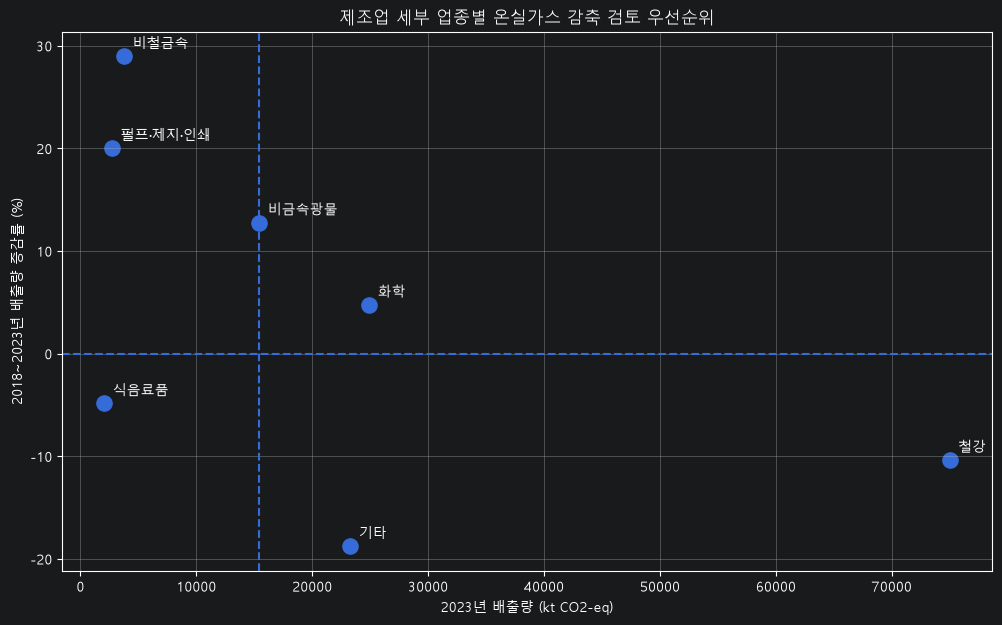

In [74]:
# 2023년 배출량과 최근 증감률을 이용해
# 제조업 세부 업종의 감축 검토 우선순위를 시각화하기 위한 코드

plt.figure(figsize=(12, 7))

plt.scatter(
    plot_df[2023],
    plot_df["증감률(%)"],
    s=120
)

# 각 점 옆에 업종명을 표시
for _, row in plot_df.iterrows():
    plt.annotate(
        row["업종명"],
        (row[2023], row["증감률(%)"]),
        xytext=(6, 6),
        textcoords="offset points"
    )

# 배출량 중앙값을 기준으로 세로 기준선 표시
plt.axvline(
    emission_median,
    linestyle="--"
)

# 증가와 감소를 구분하기 위해 증감률 0%에 가로 기준선 표시
plt.axhline(
    0,
    linestyle="--"
)

plt.title("제조업 세부 업종별 온실가스 감축 검토 우선순위")
plt.xlabel("2023년 배출량 (kt CO2-eq)")
plt.ylabel("2018~2023년 배출량 증감률 (%)")

plt.grid(True)
plt.show()

제조업 세부 업종의 현재 배출 규모와 최근 변화 방향을
동시에 비교하기 위해 산점도로 시각화했다.

x축에는 2023년 배출량을 사용했고,
y축에는 2018년 대비 2023년 배출량 증감률을 사용했다.

또한 2023년 배출량의 중앙값과 증감률 0%를 기준선으로 설정해
업종을 네 가지 영역으로 구분했다.

분석 결과 화학과 비금속광물은
배출 규모가 비교적 크면서 최근 배출량도 증가하는 영역에 위치했다.

철강은 제조업 중 가장 큰 배출 규모를 가지고 있지만,
2018년보다 2023년 배출량이 감소해 다른 영역에 위치했다.

이를 통해 배출량 규모만으로 우선순위를 판단하기보다
현재 배출 규모와 최근 변화 방향을 같이 확인하는 것이
추가적인 관리가 필요한 업종을 찾는 데 도움이 된다는 것을 확인했다.


In [75]:
# MySQL 비밀번호를 코드에 직접 저장하지 않고 입력받기 위한 코드

from getpass import getpass

mysql_password = getpass("ghg_user 비밀번호를 입력하세요: ")

In [76]:
# 프로젝트 전용 계정인 ghg_user를 사용해
# ghg_project 데이터베이스에 연결하기 위한 코드

from sqlalchemy import create_engine, text, URL

db_url = URL.create(
    drivername="mysql+pymysql",
    username="ghg_user",
    password=mysql_password,
    host="localhost",
    port=3306,
    database="ghg_project",
    query={"charset": "utf8mb4"}
)

engine = create_engine(db_url)

In [77]:
# Python에서 MySQL 계정과 데이터베이스에
# 정상적으로 연결됐는지 확인하기 위한 코드

with engine.connect() as conn:
    result = conn.execute(
        text("""
        SELECT
            USER(),
            CURRENT_USER(),
            DATABASE();
        """)
    )

    print(result.fetchone())

('ghg_user@localhost', 'ghg_user@localhost', 'ghg_project')


In [78]:
# Pandas에서 전처리한 long_df 데이터를
# MySQL의 ghg_inventory 테이블로 저장하기 위한 코드

long_df.to_sql(
    name="ghg_inventory",
    con=engine,
    if_exists="replace",
    index=False,
    chunksize=1000
)

print("ghg_inventory 테이블 저장 완료")

ghg_inventory 테이블 저장 완료


In [79]:
# MySQL에 저장된 온실가스 데이터의 전체 행 개수를 확인하기 위한 코드

check_count = pd.read_sql(
    text("""
        SELECT COUNT(*) AS 행개수
        FROM ghg_inventory;
    """),
    engine
)

check_count

,행개수
0,5508


In [80]:
# MySQL에 저장된 데이터가 정상적으로 들어갔는지
# 처음 5개 행을 조회하기 위한 코드

sql_check = pd.read_sql(
    text("""
        SELECT
            `분야 및 연도`,
            연도,
            배출량,
            상태
        FROM ghg_inventory
        LIMIT 5;
    """),
    engine
)

sql_check

,분야 및 연도,연도,배출량,상태
0,총배출량(kt CO2-eq),1990,310565.51,수치
1,순배출량,1990,271459.59,수치
2,에너지,1990,234518.00,수치
3,A 연료연소,1990,223523.85,수치
4,A 연료연소_1 에너지산업,1990,42004.07,수치


In [81]:
sql_check = pd.read_sql(
    text("""
        SELECT
            `분야 및 연도`,
            연도,
            배출량,
            상태
        FROM ghg_inventory
        LIMIT 5;
    """),
    engine
)

sql_check

,분야 및 연도,연도,배출량,상태
0,총배출량(kt CO2-eq),1990,310565.51,수치
1,순배출량,1990,271459.59,수치
2,에너지,1990,234518.00,수치
3,A 연료연소,1990,223523.85,수치
4,A 연료연소_1 에너지산업,1990,42004.07,수치


In [82]:
# SQL을 사용해 2023년 주요 분야별 배출량을 조회하기 위한 코드

sql_2023 = pd.read_sql(
    text("""
        SELECT
            `분야 및 연도` AS `분야`,
            ROUND(`배출량`, 2) AS `배출량`
        FROM `ghg_inventory`
        WHERE `연도` = 2023
          AND `분야 및 연도` IN (
              '에너지',
              '산업공정 및 제품사용',
              '농업',
              '폐기물'
          )
        ORDER BY `배출량` DESC;
    """),
    engine
)

sql_2023

,분야,배출량
0,에너지,544988.30
1,산업공정 및 제품사용,121502.15
2,농업,22537.34
3,폐기물,18172.00


In [83]:
# SQL을 사용해 2023년 총배출량 대비
# 주요 분야별 배출 비중을 계산하기 위한 코드

sql_2023_share = pd.read_sql(
    text("""
        SELECT
            `분야 및 연도` AS `분야`,

            ROUND(
                `배출량`,
                2
            ) AS `배출량`,

            ROUND(
                `배출량`
                /
                (
                    SELECT `배출량`
                    FROM `ghg_inventory`
                    WHERE `연도` = 2023
                      AND `분야 및 연도` = '총배출량(kt CO2-eq)'
                )
                * 100,
                2
            ) AS `비중(%)`

        FROM `ghg_inventory`

        WHERE `연도` = 2023
          AND `분야 및 연도` IN (
              '에너지',
              '산업공정 및 제품사용',
              '농업',
              '폐기물'
          )

        ORDER BY `배출량` DESC;
    """),
    engine
)

sql_2023_share

,분야,배출량,비중(%)
0,에너지,544988.30,77.06
1,산업공정 및 제품사용,121502.15,17.18
2,농업,22537.34,3.19
3,폐기물,18172.00,2.57


### SQL을 이용한 2023년 분야별 배출구조 분석

Pandas에서 전처리한 온실가스 데이터를 MySQL에 저장한 뒤
SQL을 사용해 2023년 주요 분야별 배출량을 조회했다.

WHERE와 IN을 사용해
에너지, 산업공정 및 제품사용, 농업, 폐기물 분야만 선택했다.

또한 서브쿼리를 사용해 2023년 총배출량을 가져오고,
각 분야의 배출량을 총배출량으로 나누어 비중을 계산했다.

분석 결과 에너지가 약 77.06%로 가장 높은 비중을 차지했고,
산업공정 및 제품사용은 약 17.18%,
농업은 약 3.19%, 폐기물은 약 2.57%로 나타났다.

이를 통해 Pandas에서 확인했던 배출구조를
SQL에서도 동일하게 분석할 수 있다는 것을 확인했다.

In [84]:
# SQL을 사용해 1990년과 2023년의 주요 분야별 배출량을 비교하고
# 장기적인 증감량과 증감률을 계산하기 위한 코드

sql_change = pd.read_sql(
    text("""
        SELECT
            `분야 및 연도` AS `분야`,

            MAX(
                IF(`연도` = 1990, `배출량`, NULL)
            ) AS `1990년 배출량`,

            MAX(
                IF(`연도` = 2023, `배출량`, NULL)
            ) AS `2023년 배출량`,

            ROUND(
                MAX(IF(`연도` = 2023, `배출량`, NULL))
                -
                MAX(IF(`연도` = 1990, `배출량`, NULL)),
                2
            ) AS `증감량`,

            ROUND(
                (
                    MAX(IF(`연도` = 2023, `배출량`, NULL))
                    -
                    MAX(IF(`연도` = 1990, `배출량`, NULL))
                )
                /
                NULLIF(
                    MAX(IF(`연도` = 1990, `배출량`, NULL)),
                    0
                )
                * 100,
                2
            ) AS `증감률(%)`

        FROM `ghg_inventory`

        WHERE `분야 및 연도` IN (
            '에너지',
            '산업공정 및 제품사용',
            '농업',
            '폐기물'
        )

        GROUP BY `분야 및 연도`;
    """),
    engine
)

sql_change

,분야,1990년 배출량,2023년 배출량,증감량,증감률(%)
0,에너지,234518.00,544988.30,310470.30,132.39
1,산업공정 및 제품사용,37807.90,121502.15,83694.25,221.37
2,농업,24800.27,22537.34,-2262.93,-9.12
3,폐기물,13439.35,18172.00,4732.65,35.21


### SQL을 이용한 1990년과 2023년 배출량 비교

1990년과 2023년의 주요 분야별 배출량 변화를
SQL을 사용해 비교했다.

IF와 MAX를 사용해 각 분야의 1990년과 2023년 배출량을
한 행에서 비교할 수 있도록 만들었다.

이후 2023년 배출량에서 1990년 배출량을 빼 증감량을 계산하고,
1990년 배출량을 기준으로 증감률도 계산했다.

분석 결과 에너지 분야는 약 310,470 kt CO2-eq 증가해
실제 증가량이 가장 크게 나타났다.

산업공정 및 제품사용은 약 83,694 kt CO2-eq 증가했으며,
증가율은 약 221.37%로 가장 높았다.

반면 농업은 1990년보다 약 2,263 kt CO2-eq 감소했다.

이를 통해 Pandas에서 확인했던 장기적인 배출량 변화를

In [85]:
# SQL을 사용해 2018년과 2023년의 주요 분야별 배출량 변화를 비교하고
# 국가 총배출량 감소에서 각 분야가 차지하는 감소 기여도를 계산하기 위한 코드

sql_recent_change = pd.read_sql(
    text("""
        SELECT
            `분야 및 연도` AS `분야`,

            MAX(
                IF(`연도` = 2018, `배출량`, NULL)
            ) AS `2018년 배출량`,

            MAX(
                IF(`연도` = 2023, `배출량`, NULL)
            ) AS `2023년 배출량`,

            ROUND(
                MAX(IF(`연도` = 2023, `배출량`, NULL))
                -
                MAX(IF(`연도` = 2018, `배출량`, NULL)),
                2
            ) AS `증감량`,

            ROUND(
                (
                    MAX(IF(`연도` = 2023, `배출량`, NULL))
                    -
                    MAX(IF(`연도` = 2018, `배출량`, NULL))
                )
                /
                NULLIF(
                    MAX(IF(`연도` = 2018, `배출량`, NULL)),
                    0
                )
                * 100,
                2
            ) AS `증감률(%)`,

            ROUND(
                (
                    MAX(IF(`연도` = 2023, `배출량`, NULL))
                    -
                    MAX(IF(`연도` = 2018, `배출량`, NULL))
                )
                /
                (
                    (
                        SELECT `배출량`
                        FROM `ghg_inventory`
                        WHERE `연도` = 2023
                          AND `분야 및 연도` = '총배출량(kt CO2-eq)'
                    )
                    -
                    (
                        SELECT `배출량`
                        FROM `ghg_inventory`
                        WHERE `연도` = 2018
                          AND `분야 및 연도` = '총배출량(kt CO2-eq)'
                    )
                )
                * 100,
                2
            ) AS `감소기여도(%)`

        FROM `ghg_inventory`

        WHERE `분야 및 연도` IN (
            '에너지',
            '산업공정 및 제품사용',
            '농업',
            '폐기물'
        )

        GROUP BY `분야 및 연도`;
    """),
    engine
)

sql_recent_change

,분야,2018년 배출량,2023년 배출량,증감량,증감률(%),감소기여도(%)
0,에너지,613672.85,544988.30,-68684.55,-11.19,94.17
1,산업공정 및 제품사용,123823.34,121502.15,-2321.19,-1.87,3.18
2,농업,23307.54,22537.34,-770.20,-3.30,1.06
3,폐기물,19336.59,18172.00,-1164.59,-6.02,1.60


### SQL을 이용한 최근 배출 감소 기여도 분석

2018년 이후 국가 총배출량 감소에
각 분야가 얼마나 영향을 주었는지 SQL을 사용해 확인했다.

IF와 MAX를 사용해 각 분야의 2018년과 2023년 배출량을 비교하고,
두 연도의 차이를 이용해 증감량과 증감률을 계산했다.

또한 서브쿼리를 이용해 2018년과 2023년의 국가 총배출량을 가져오고,
각 분야의 증감량을 전체 총배출량 증감량과 비교해 감소 기여도를 계산했다.

분석 결과 에너지 분야의 감소 기여도는 약 94.17%로
주요 분야 중 가장 높게 나타났다.

산업공정 및 제품사용은 약 3.18%,
폐기물은 약 1.60%,
농업은 약 1.06%로 나타났다.

이를 통해 Pandas에서 확인했던 것과 동일하게
2018년 이후 국가 총배출량 감소는
대부분 에너지 분야의 감소에서 나타났다는 것을 SQL에서도 확인했다.

In [86]:
# SQL을 사용해 2018년과 2023년의 에너지 세부 분야별 배출량을 비교하고
# 에너지 전체 감소량에서 각 세부 분야가 차지하는 감소 기여도를 계산하기 위한 코드

sql_energy_detail = pd.read_sql(
    text("""
        SELECT
            `분야 및 연도` AS `세부분야`,

            MAX(
                IF(`연도` = 2018, `배출량`, NULL)
            ) AS `2018년 배출량`,

            MAX(
                IF(`연도` = 2023, `배출량`, NULL)
            ) AS `2023년 배출량`,

            ROUND(
                MAX(IF(`연도` = 2023, `배출량`, NULL))
                -
                MAX(IF(`연도` = 2018, `배출량`, NULL)),
                2
            ) AS `증감량`,

            ROUND(
                (
                    MAX(IF(`연도` = 2023, `배출량`, NULL))
                    -
                    MAX(IF(`연도` = 2018, `배출량`, NULL))
                )
                /
                NULLIF(
                    MAX(IF(`연도` = 2018, `배출량`, NULL)),
                    0
                )
                * 100,
                2
            ) AS `증감률(%)`,

            ROUND(
                (
                    MAX(IF(`연도` = 2023, `배출량`, NULL))
                    -
                    MAX(IF(`연도` = 2018, `배출량`, NULL))
                )
                /
                NULLIF(
                    (
                        SELECT `배출량`
                        FROM `ghg_inventory`
                        WHERE `연도` = 2023
                          AND `분야 및 연도` = '에너지'
                    )
                    -
                    (
                        SELECT `배출량`
                        FROM `ghg_inventory`
                        WHERE `연도` = 2018
                          AND `분야 및 연도` = '에너지'
                    ),
                    0
                )
                * 100,
                2
            ) AS `감소기여도(%)`

        FROM `ghg_inventory`

        WHERE `연도` IN (2018, 2023)
          AND `분야 및 연도` IN (
              'A 연료연소_1 에너지산업',
              'A 연료연소_2 제조업 및 건설업_2 제조업 및 건설업',
              'A 연료연소_3 수송',
              'A 연료연소_4 기타',
              'A 연료연소_5 미분류',
              'B 탈루'
          )

        GROUP BY `분야 및 연도`;
    """),
    engine
)

sql_energy_detail

,세부분야,2018년 배출량,2023년 배출량,증감량,증감률(%),감소기여도(%)
0,A 연료연소_1 에너지산업,297732.94,248155.39,-49577.55,-16.65,72.18
1,A 연료연소_2 제조업 및 건설업_2 제조업 및 건설업,157209.46,147240.38,-9969.08,-6.34,14.51
2,A 연료연소_3 수송,98882.39,97825.94,-1056.45,-1.07,1.54
3,A 연료연소_4 기타,53012.02,45502.68,-7509.34,-14.17,10.93
4,A 연료연소_5 미분류,3148.07,3021.92,-126.15,-4.01,0.18
5,B 탈루,3687.98,3241.99,-445.99,-12.09,0.65


### SQL을 이용한 에너지 세부 분야 감소 기여도 분석

2018년 이후 국가 총배출량 감소에 에너지 분야가 가장 큰 영향을 주었기 때문에
에너지 분야 안에서 어떤 세부 분야의 감소가 컸는지 SQL로 확인했다.

에너지산업, 제조업 및 건설업, 수송, 기타, 미분류, 탈루의
2018년과 2023년 배출량을 비교했다.

분석 결과 에너지산업은 약 49,578 kt CO2-eq 감소했으며,
에너지 전체 감소량에서 약 72.18%를 차지해
가장 높은 감소 기여도를 보였다.

제조업 및 건설업은 약 14.51%,
기타는 약 10.93%의 감소 기여도를 보였다.

이를 통해 국가 총배출량 감소에 에너지 분야가 큰 영향을 주었고,
에너지 분야 안에서는 에너지산업의 감소가 가장 큰 영향을 주었다는 것을
SQL에서도 확인할 수 있었다.

In [87]:
# SQL을 사용해 에너지산업 세부 분야의 2018년과 2023년 배출량을 비교하고
# 에너지산업 전체 감소량에서 각 세부 분야가 차지하는 기여도를 계산하기 위한 코드

sql_energy_industry = pd.read_sql(
    text("""
        SELECT
            `분야 및 연도` AS `세부분야`,

            MAX(
                IF(`연도` = 2018, `배출량`, NULL)
            ) AS `2018년 배출량`,

            MAX(
                IF(`연도` = 2023, `배출량`, NULL)
            ) AS `2023년 배출량`,

            ROUND(
                MAX(IF(`연도` = 2023, `배출량`, NULL))
                -
                MAX(IF(`연도` = 2018, `배출량`, NULL)),
                2
            ) AS `증감량`,

            ROUND(
                (
                    MAX(IF(`연도` = 2023, `배출량`, NULL))
                    -
                    MAX(IF(`연도` = 2018, `배출량`, NULL))
                )
                /
                NULLIF(
                    MAX(IF(`연도` = 2018, `배출량`, NULL)),
                    0
                )
                * 100,
                2
            ) AS `증감률(%)`,

            ROUND(
                (
                    MAX(IF(`연도` = 2023, `배출량`, NULL))
                    -
                    MAX(IF(`연도` = 2018, `배출량`, NULL))
                )
                /
                NULLIF(
                    (
                        SELECT `배출량`
                        FROM `ghg_inventory`
                        WHERE `연도` = 2023
                          AND `분야 및 연도` = 'A 연료연소_1 에너지산업'
                    )
                    -
                    (
                        SELECT `배출량`
                        FROM `ghg_inventory`
                        WHERE `연도` = 2018
                          AND `분야 및 연도` = 'A 연료연소_1 에너지산업'
                    ),
                    0
                )
                * 100,
                2
            ) AS `감소기여도(%)`

        FROM `ghg_inventory`

        WHERE `연도` IN (2018, 2023)
          AND `분야 및 연도` IN (
              'A 연료연소_a 공공 전기 및 열 생산',
              'A 연료연소_b 석유정제',
              'A 연료연소_c 고체연료 제조 및 기타 에너지 산업'
          )

        GROUP BY `분야 및 연도`;
    """),
    engine
)

sql_energy_industry

,세부분야,2018년 배출량,2023년 배출량,증감량,증감률(%),감소기여도(%)
0,A 연료연소_a 공공 전기 및 열 생산,276618.81,226959.86,-49658.95,-17.95,100.16
1,A 연료연소_b 석유정제,20289.29,19605.15,-684.14,-3.37,1.38
2,A 연료연소_c 고체연료 제조 및 기타 에너지 산업,824.84,1590.37,765.53,92.81,-1.54


### SQL을 이용한 에너지산업 세부 분야 분석

에너지 분야 감소에 가장 큰 영향을 준 에너지산업을
세부 분야별로 나누어 SQL로 확인했다.

공공 전기 및 열 생산, 석유정제,
고체연료 제조 및 기타 에너지 산업의
2018년과 2023년 배출량을 비교했다.

분석 결과 공공 전기 및 열 생산은
약 49,659 kt CO2-eq 감소해 가장 큰 감소폭을 보였다.

석유정제도 소폭 감소했지만,
고체연료 제조 및 기타 에너지 산업은 오히려 배출량이 증가했다.

공공 전기 및 열 생산의 감소 기여도는 약 100.16%로 나타났다.

100%를 넘은 이유는 공공 전기 및 열 생산에서 발생한 감소량의 일부가
고체연료 제조 및 기타 에너지 산업의 증가로 상쇄되었기 때문이다.

이를 통해 2018년 이후 에너지산업의 배출 감소는
주로 공공 전기 및 열 생산 부문의 감소에서 나타났다는 것을 확인했다.

In [88]:
# SQL을 사용해 제조업 및 건설업 세부 업종의
# 2018년과 2023년 배출량, 증감량, 증감률, 2023년 비중을 계산하기 위한 코드

sql_manufacturing = pd.read_sql(
    text("""
        SELECT
            `분야 및 연도` AS `세부분야`,

            MAX(
                IF(`연도` = 2018, `배출량`, NULL)
            ) AS `2018년 배출량`,

            MAX(
                IF(`연도` = 2023, `배출량`, NULL)
            ) AS `2023년 배출량`,

            ROUND(
                MAX(IF(`연도` = 2023, `배출량`, NULL))
                -
                MAX(IF(`연도` = 2018, `배출량`, NULL)),
                2
            ) AS `증감량`,

            ROUND(
                (
                    MAX(IF(`연도` = 2023, `배출량`, NULL))
                    -
                    MAX(IF(`연도` = 2018, `배출량`, NULL))
                )
                /
                NULLIF(
                    MAX(IF(`연도` = 2018, `배출량`, NULL)),
                    0
                )
                * 100,
                2
            ) AS `증감률(%)`,

            ROUND(
                MAX(IF(`연도` = 2023, `배출량`, NULL))
                /
                (
                    SELECT `배출량`
                    FROM `ghg_inventory`
                    WHERE `연도` = 2023
                      AND `분야 및 연도`
                          = 'A 연료연소_2 제조업 및 건설업_2 제조업 및 건설업'
                )
                * 100,
                2
            ) AS `2023년 비중(%)`

        FROM `ghg_inventory`

        WHERE `연도` IN (2018, 2023)
          AND `분야 및 연도` IN (
              'A 연료연소_a 철강',
              'A 연료연소_b 비철금속',
              'A 연료연소_c 화학',
              'A 연료연소_d 펄프, 제지 및 인쇄',
              'A 연료연소_e 식음료품 가공 및 담배 제조',
              'A 연료연소_f 비금속광물',
              'A 연료연소_g 기타'
          )

        GROUP BY `분야 및 연도`

        ORDER BY `2023년 배출량` DESC;
    """),
    engine
)

sql_manufacturing

,세부분야,2018년 배출량,2023년 배출량,증감량,증감률(%),2023년 비중(%)
0,A 연료연소_a 철강,83663.20,74997.26,-8665.94,-10.36,50.94
1,A 연료연소_c 화학,23795.11,24925.76,1130.65,4.75,16.93
2,A 연료연소_g 기타,28677.37,23293.66,-5383.71,-18.77,15.82
3,A 연료연소_f 비금속광물,13684.83,15432.97,1748.14,12.77,10.48
4,A 연료연소_b 비철금속,2927.06,3775.43,848.37,28.98,2.56
5,"A 연료연소_d 펄프, 제지 및 인쇄",2291.56,2750.24,458.68,20.02,1.87
6,A 연료연소_e 식음료품 가공 및 담배 제조,2170.33,2065.05,-105.28,-4.85,1.40


### SQL을 이용한 제조업 및 건설업 세부 업종 분석

에너지 분야에서 두 번째로 감소 규모가 컸던
제조업 및 건설업을 세부 업종별로 분석했다.

철강, 비철금속, 화학, 펄프·제지 및 인쇄,
식음료품 가공 및 담배 제조, 비금속광물, 기타 업종의
2018년과 2023년 배출량을 SQL로 비교했다.

분석 결과 2023년 기준 철강이 제조업 및 건설업 배출량의
약 50.94%를 차지해 가장 큰 비중을 보였다.

철강과 기타 업종은 2018년보다 배출량이 감소했지만,
화학과 비금속광물 등 일부 업종은 배출량이 증가했다.

따라서 감축 우선순위를 판단할 때는
현재 배출량의 규모뿐 아니라 최근 배출량의 증가 여부도
함께 고려할 필요가 있다고 판단했다.

In [90]:
# 제조업 세부 업종의 2023년 배출 규모와 최근 증감 방향을 이용해
# 감축 우선순위 점수를 계산하기 위한 코드

priority_df = sql_manufacturing.copy()

median_emission = priority_df["2023년 배출량"].median()

priority_df["규모점수"] = (
    priority_df["2023년 배출량"] >= median_emission
).astype(int) * 2

priority_df["증가점수"] = (
    priority_df["증감량"] > 0
).astype(int)

priority_df["우선순위점수"] = (
    priority_df["규모점수"]
    +
    priority_df["증가점수"]
)

priority_df

,세부분야,2018년 배출량,2023년 배출량,증감량,증감률(%),2023년 비중(%),규모점수,증가점수,우선순위점수
0,A 연료연소_a 철강,83663.20,74997.26,-8665.94,-10.36,50.94,2,0,2
1,A 연료연소_c 화학,23795.11,24925.76,1130.65,4.75,16.93,2,1,3
2,A 연료연소_g 기타,28677.37,23293.66,-5383.71,-18.77,15.82,2,0,2
3,A 연료연소_f 비금속광물,13684.83,15432.97,1748.14,12.77,10.48,2,1,3
4,A 연료연소_b 비철금속,2927.06,3775.43,848.37,28.98,2.56,0,1,1
5,"A 연료연소_d 펄프, 제지 및 인쇄",2291.56,2750.24,458.68,20.02,1.87,0,1,1
6,A 연료연소_e 식음료품 가공 및 담배 제조,2170.33,2065.05,-105.28,-4.85,1.40,0,0,0


In [91]:
# 계산된 우선순위 점수를
# 1순위부터 4순위까지의 등급으로 변환하기 위한 코드

priority_df["감축우선순위"] = priority_df["우선순위점수"].map({
    3: "1순위",
    2: "2순위",
    1: "3순위",
    0: "4순위"
})

priority_df = priority_df.sort_values(
    by=["우선순위점수", "2023년 배출량"],
    ascending=[False, False]
)

priority_df[
    [
        "세부분야",
        "2023년 배출량",
        "증감량",
        "증감률(%)",
        "규모점수",
        "증가점수",
        "우선순위점수",
        "감축우선순위"
    ]
]

,세부분야,2023년 배출량,증감량,증감률(%),규모점수,증가점수,우선순위점수,감축우선순위
1,A 연료연소_c 화학,24925.76,1130.65,4.75,2,1,3,1순위
3,A 연료연소_f 비금속광물,15432.97,1748.14,12.77,2,1,3,1순위
0,A 연료연소_a 철강,74997.26,-8665.94,-10.36,2,0,2,2순위
2,A 연료연소_g 기타,23293.66,-5383.71,-18.77,2,0,2,2순위
4,A 연료연소_b 비철금속,3775.43,848.37,28.98,0,1,1,3순위
5,"A 연료연소_d 펄프, 제지 및 인쇄",2750.24,458.68,20.02,0,1,1,3순위
6,A 연료연소_e 식음료품 가공 및 담배 제조,2065.05,-105.28,-4.85,0,0,0,4순위


### 제조업 세부 업종 감축 우선순위 도출

제조업 및 건설업 세부 업종의 감축 우선순위를
현재 배출 규모와 최근 배출량 증가 여부를 기준으로 분석했다.

2023년 배출량이 업종별 중앙값 이상이면 규모점수 2점,
2018년보다 2023년 배출량이 증가했다면 증가점수 1점을 부여했다.

두 점수를 합산해 3점은 1순위,
2점은 2순위, 1점은 3순위, 0점은 4순위로 구분했다.

분석 결과 화학과 비금속광물이
배출 규모가 크면서 최근 배출량도 증가해 1순위로 나타났다.

철강은 가장 큰 배출 규모를 보였지만
2018년 이후 배출량이 감소하고 있어 2순위로 분류했다.

다만 이 결과는 배출 규모와 최근 증가 여부만 이용한
1차적인 데이터 기반 우선순위이다.

실제 감축 정책이나 기업 투자 우선순위를 판단하기 위해서는
감축 비용, 기술 적용 가능성, 생산량, 규제 등의 요소를
추가로 고려할 필요가 있다.

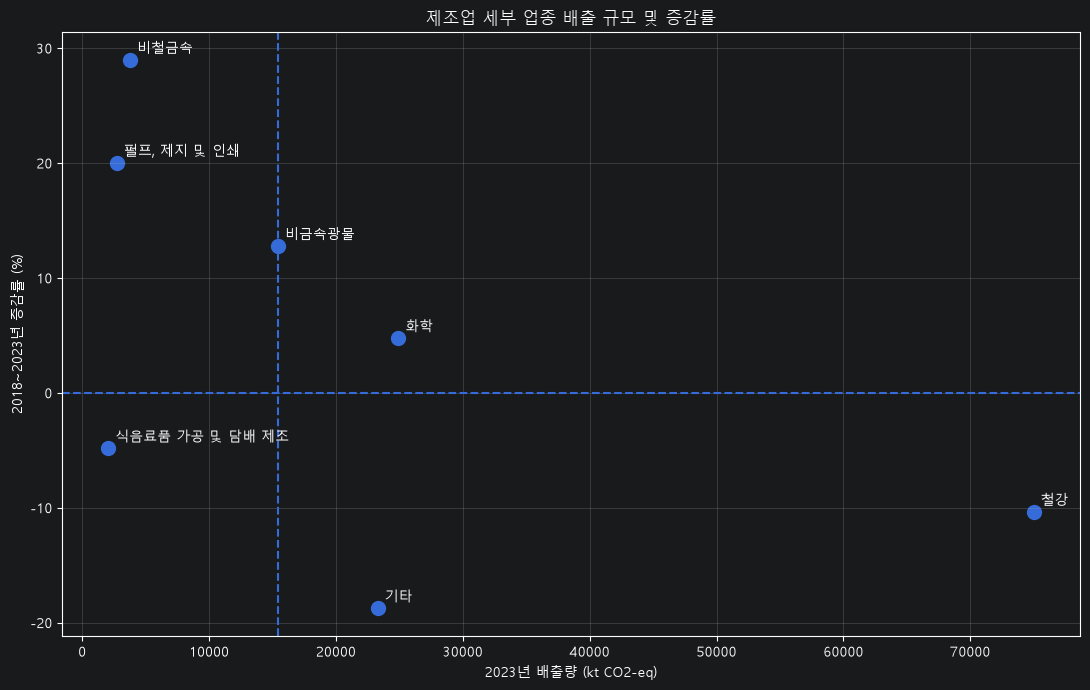

In [92]:
# 제조업 세부 업종의 배출 규모와 최근 증감률을
# 산점도로 시각화하기 위한 코드

priority_plot = priority_df.copy()

# 그래프에서 보기 쉽게 업종명 앞의 코드 부분 제거
priority_plot["업종"] = priority_plot["세부분야"].str.replace(
    r"^A 연료연소_[a-g] ",
    "",
    regex=True
)

plt.figure(figsize=(11, 7))

plt.scatter(
    priority_plot["2023년 배출량"],
    priority_plot["증감률(%)"],
    s=100
)

# 배출량 중앙값 기준선
plt.axvline(
    x=median_emission,
    linestyle="--"
)

# 증감률 0% 기준선
plt.axhline(
    y=0,
    linestyle="--"
)

# 각 점에 업종명 표시
for _, row in priority_plot.iterrows():
    plt.annotate(
        row["업종"],
        (row["2023년 배출량"], row["증감률(%)"]),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("2023년 배출량 (kt CO2-eq)")
plt.ylabel("2018~2023년 증감률 (%)")
plt.title("제조업 세부 업종 배출 규모 및 증감률")

plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

### 제조업 세부 업종 감축 우선순위 시각화

2023년 배출량을 X축,
2018~2023년 배출량 증감률을 Y축으로 설정해
제조업 세부 업종의 배출 특성을 시각화했다.

세로 기준선은 2023년 업종별 배출량의 중앙값이며,
가로 기준선은 증감률 0%를 의미한다.

오른쪽 위 영역은 배출 규모가 크면서
최근 배출량도 증가한 업종을 의미한다.

분석 결과 화학과 비금속광물이
배출 규모와 최근 증가 추세를 동시에 보여
1차적인 감축 우선 검토 대상으로 나타났다.

반면 철강은 2023년 배출 규모가 가장 크지만
2018년 이후 배출량이 감소하고 있어
화학 및 비금속광물과 다른 특성을 보였다.

이 시각화를 통해 배출량의 절대적인 규모뿐만 아니라
최근 변화 방향을 함께 고려할 필요가 있음을 확인했다.

In [93]:
# 지금까지 분석한 결과에서 핵심 수치를 가져와
# 최종 분석 요약표를 만들기 위한 코드

energy_contribution = sql_recent_change.loc[
    sql_recent_change["분야"] == "에너지",
    "감소기여도(%)"
].iloc[0]

energy_industry_contribution = sql_energy_detail.loc[
    sql_energy_detail["세부분야"] == "A 연료연소_1 에너지산업",
    "감소기여도(%)"
].iloc[0]

power_contribution = sql_energy_industry.loc[
    sql_energy_industry["세부분야"] == "A 연료연소_a 공공 전기 및 열 생산",
    "감소기여도(%)"
].iloc[0]

priority_1 = priority_df.loc[
    priority_df["감축우선순위"] == "1순위",
    "세부분야"
].str.replace(
    r"^A 연료연소_[a-g] ",
    "",
    regex=True
).tolist()

final_summary = pd.DataFrame({
    "분석단계": [
        "국가 전체",
        "에너지 분야",
        "에너지산업",
        "제조업 및 건설업"
    ],

    "핵심결과": [
        f"2018~2023년 국가 배출량 감소의 {energy_contribution:.2f}%가 에너지 분야에서 발생",
        f"에너지 분야 감소의 {energy_industry_contribution:.2f}%가 에너지산업에서 발생",
        f"에너지산업 감소의 {power_contribution:.2f}%가 공공 전기 및 열 생산에서 발생",
        f"감축 우선 검토 업종: {', '.join(priority_1)}"
    ]
})

final_summary

,분석단계,핵심결과
0,국가 전체,2018~2023년 국가 배출량 감소의 94.17%가 에너지 분야에서 발생
1,에너지 분야,에너지 분야 감소의 72.18%가 에너지산업에서 발생
2,에너지산업,에너지산업 감소의 100.16%가 공공 전기 및 열 생산에서 발생
3,제조업 및 건설업,"감축 우선 검토 업종: 화학, 비금속광물"


## 최종 분석 결과

1990~2023년 국가 온실가스 인벤토리 데이터를
Python, Pandas, MySQL을 활용해 분석했다.

### 1. 국가 배출구조

2023년 국가 총배출량에서 에너지 분야가 약 77%를 차지해
가장 큰 배출원으로 나타났다.

1990년과 비교하면 에너지와 산업공정 및 제품사용 분야의
배출량이 크게 증가했다.

### 2. 최근 배출량 감소 원인

국가 총배출량이 가장 높았던 2018년과 2023년을 비교한 결과,
최근 국가 배출량 감소의 약 94%가 에너지 분야에서 발생했다.

에너지 분야를 세부적으로 분석한 결과,
에너지산업이 에너지 분야 감소의 약 72%를 차지했다.

에너지산업에서는 공공 전기 및 열 생산 부문의 감소가
전체 감소를 주도한 것으로 나타났다.

### 3. 제조업 감축 우선순위

제조업 및 건설업은 세부 업종별로
2023년 배출 규모와 2018~2023년 증감 방향을 비교했다.

철강은 가장 큰 배출 규모를 보였지만 최근 배출량이 감소했다.

반면 화학과 비금속광물은
배출 규모가 일정 수준 이상이면서 최근 배출량도 증가해
1차적인 감축 우선 검토 대상으로 분류했다.

다만 이번 우선순위는 배출 규모와 증감 방향을 기준으로 한
1차적인 데이터 분석 결과이다.

실제 감축 정책이나 기업의 투자 우선순위를 결정하기 위해서는
감축 비용, 기술 적용 가능성, 생산량, 에너지 사용량,
규제 수준 등의 추가적인 분석이 필요하다.

In [94]:
# 분석 결과를 저장할 output 폴더가 없으면
# 새로 생성하기 위한 코드

from pathlib import Path

output_path = Path("../output")

output_path.mkdir(
    parents=True,
    exist_ok=True
)

output_path

WindowsPath('../output')

In [95]:
# 지금까지 분석한 주요 결과표를
# output 폴더에 CSV 파일로 저장하기 위한 코드

sql_2023_share.to_csv(
    output_path / "2023_분야별_배출비중.csv",
    index=False,
    encoding="utf-8-sig"
)

sql_change.to_csv(
    output_path / "1990_2023_분야별_변화.csv",
    index=False,
    encoding="utf-8-sig"
)

sql_recent_change.to_csv(
    output_path / "2018_2023_감소기여도.csv",
    index=False,
    encoding="utf-8-sig"
)

sql_energy_detail.to_csv(
    output_path / "에너지_세부분야_분석.csv",
    index=False,
    encoding="utf-8-sig"
)

sql_manufacturing.to_csv(
    output_path / "제조업_세부업종_분석.csv",
    index=False,
    encoding="utf-8-sig"
)

priority_df.to_csv(
    output_path / "제조업_감축우선순위.csv",
    index=False,
    encoding="utf-8-sig"
)

final_summary.to_csv(
    output_path / "최종_분석요약.csv",
    index=False,
    encoding="utf-8-sig"
)

In [96]:
# output 폴더에 저장된 파일 목록을 확인하기 위한 코드

for file in output_path.iterdir():
    print(file.name)

1990_2023_분야별_변화.csv
2018_2023_감소기여도.csv
2023_분야별_배출비중.csv
에너지_세부분야_분석.csv
제조업_감축우선순위.csv
제조업_세부업종_분석.csv
최종_분석요약.csv


## 분석 결과 저장

Python과 SQL을 통해 계산한 주요 분석 결과를
CSV 파일로 저장했다.

2023년 분야별 배출비중, 장기 배출량 변화,
2018년 이후 감소 기여도, 에너지 세부 분야 분석,
제조업 세부 업종 분석과 감축 우선순위를 각각 저장했다.

이를 통해 분석 과정뿐만 아니라
최종 결과를 별도의 데이터 파일로 활용할 수 있도록 구성했다.

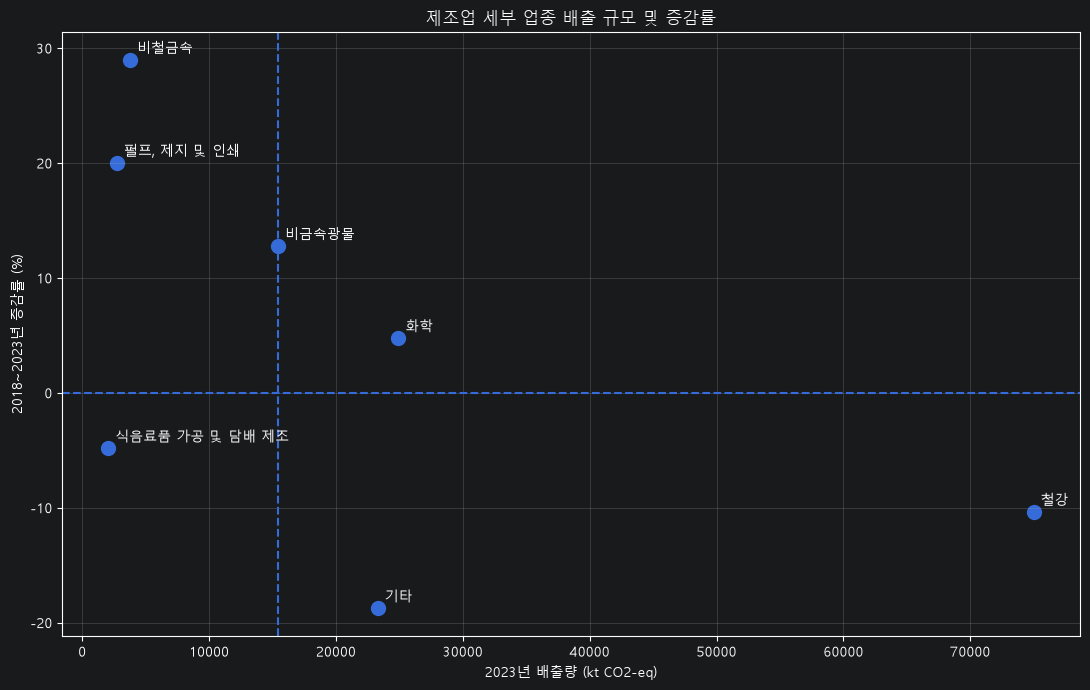

In [97]:
# 제조업 세부 업종의 배출 규모와 증감률을 시각화하고
# 그래프를 output 폴더에 PNG 파일로 저장하기 위한 코드

plt.figure(figsize=(11, 7))

plt.scatter(
    priority_plot["2023년 배출량"],
    priority_plot["증감률(%)"],
    s=100
)

# 2023년 배출량 중앙값을 기준선으로 표시
plt.axvline(
    x=median_emission,
    linestyle="--"
)

# 증감률 0%를 기준선으로 표시
plt.axhline(
    y=0,
    linestyle="--"
)

# 각 점에 업종명 표시
for _, row in priority_plot.iterrows():
    plt.annotate(
        row["업종"],
        (row["2023년 배출량"], row["증감률(%)"]),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("2023년 배출량 (kt CO2-eq)")
plt.ylabel("2018~2023년 증감률 (%)")
plt.title("제조업 세부 업종 배출 규모 및 증감률")

plt.grid(alpha=0.3)
plt.tight_layout()

# 그래프를 PNG 파일로 저장
plt.savefig(
    output_path / "제조업_감축우선순위_산점도.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [98]:
# 저장한 그래프 파일이 실제로 생성됐는지 확인하기 위한 코드

graph_path = output_path / "제조업_감축우선순위_산점도.png"

print(graph_path)
print(graph_path.exists())

..\output\제조업_감축우선순위_산점도.png
True


### 감축 우선순위 시각화 결과 저장

제조업 세부 업종의 2023년 배출량과
2018~2023년 증감률을 비교한 산점도를 PNG 파일로 저장했다.

그래프는 배출 규모와 최근 변화 방향을 함께 보여주며,
화학과 비금속광물이 배출 규모가 크면서
최근 배출량도 증가하고 있다는 점을 한눈에 확인할 수 있도록 구성했다.

생성된 그래프는 이후 README와 포트폴리오의
분석 결과 설명에 활용할 수 있도록 저장했다.

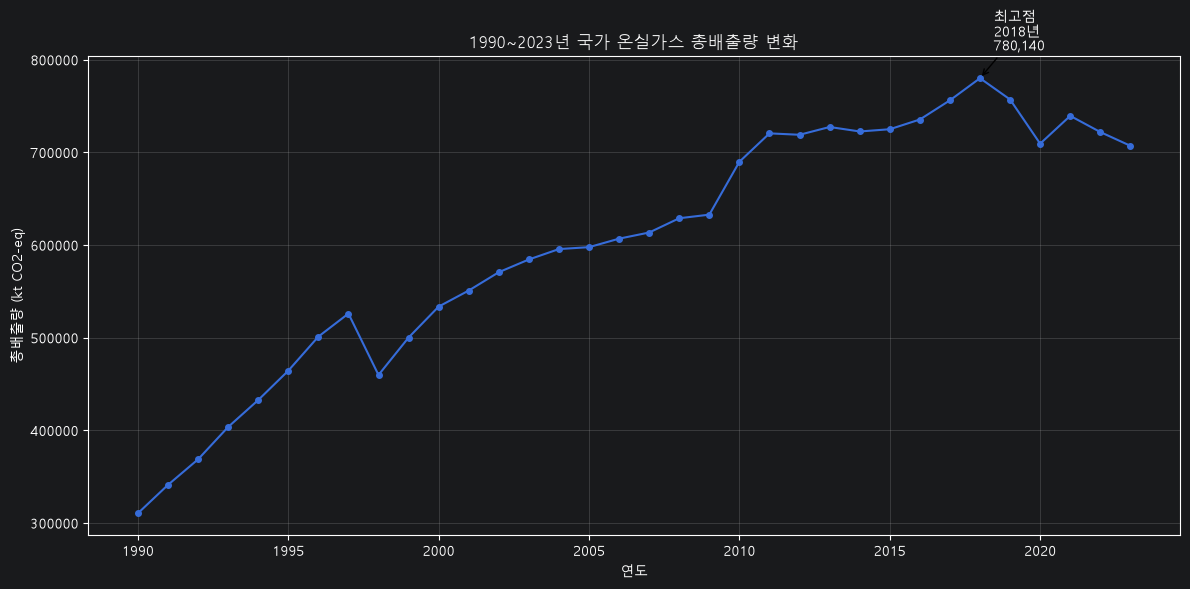

In [99]:
# 1990년부터 2023년까지 국가 총배출량의 장기 변화 추이를 시각화하고
# 그래프를 output 폴더에 PNG 파일로 저장하기 위한 코드

plt.figure(figsize=(12, 6))

plt.plot(
    total_df["연도"],
    total_df["배출량"],
    marker="o",
    markersize=4
)

# 전체 기간 중 배출량이 가장 높았던 연도와 배출량 찾기
peak_row = total_df.loc[
    total_df["배출량"].idxmax()
]

# 최고 배출량 지점을 그래프에 표시
plt.annotate(
    f'최고점\n{int(peak_row["연도"])}년\n{peak_row["배출량"]:,.0f}',
    xy=(
        peak_row["연도"],
        peak_row["배출량"]
    ),
    xytext=(10, 20),
    textcoords="offset points",
    arrowprops={"arrowstyle": "->"}
)

plt.xlabel("연도")
plt.ylabel("총배출량 (kt CO2-eq)")
plt.title("1990~2023년 국가 온실가스 총배출량 변화")

plt.grid(alpha=0.3)
plt.tight_layout()

# 그래프를 PNG 파일로 저장
plt.savefig(
    output_path / "국가_총배출량_추이_1990_2023.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [100]:
# 국가 총배출량 추이 그래프가
# output 폴더에 정상적으로 저장됐는지 확인하기 위한 코드

trend_graph_path = (
    output_path
    / "국가_총배출량_추이_1990_2023.png"
)

print(trend_graph_path)
print(trend_graph_path.exists())

..\output\국가_총배출량_추이_1990_2023.png
True


### 국가 총배출량 장기 추이 시각화

1990~2023년 국가 온실가스 총배출량의
장기적인 변화 추이를 시각화했다.

1990년 이후 총배출량은 전반적으로 증가했으며,
2018년에 분석 기간 중 가장 높은 수준을 기록했다.

이후 총배출량은 감소하는 흐름을 보였으며,
앞선 분야별 분석을 통해 최근 감소에는
에너지 분야의 변화가 가장 크게 영향을 주었다는 것을 확인했다.

장기 추이 그래프와 분야별 분석을 함께 활용해
국가 온실가스 배출구조의 변화와 최근 감소 원인을 연결해 분석했다.